# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from scipy import signal
from scipy.stats import pearsonr

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [2]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-04 00:00:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [5]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

C:\Users\chari\AppData\Local\Temp\ipykernel_24060\3086603202.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')


Storing the time values and the timestep.

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values


#pressure
p_surf = measurements_used['P0'].values*100#,measurements_used['P0'].values*100+100))   #[Pa]

#dew point temperature
T_d_arr = np.array((measurements_used['TD002'].values,measurements_used['TD002'].values+1,measurements_used['TD002'].values-1)) #[K]

#state
X = np.zeros((3,len(p_surf)))
#X1 = np.zeros(len(T_surf))
X[:,0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP
#X1[0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

In [7]:
T_surf[0]

np.float32(287.07)

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [8]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\ES25\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [9]:
P = np.zeros((3,len(p_surf)))
Z_b_arr = np.zeros((3,len(p_surf)))
Z_c_arr = np.zeros((3,len(p_surf)))
T_m_arr = np.zeros((3,len(p_surf)))
P_0 = np.zeros(len(p_surf))
f_arr = np.zeros(len(p_surf))
h_arr = np.zeros(len(p_surf))
f_arr = np.zeros((3,len(p_surf)))
v_arr = np.zeros((3,len(p_surf)))
D_c_arr = np.zeros((3,len(p_surf)))
O_b_arr = np.zeros((3,len(p_surf)))
ql_total = np.zeros((3,len(p_surf)))
phi_arr = np.zeros((3,len(p_surf)))
N_v_arr = np.zeros((3,len(p_surf))) 
p_t_arr = np.zeros((3,len(p_surf))) 

In [10]:
from GB84 import w

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [11]:
#loop for finding the precipitation given the T_0 and p

for a in range(3):
    for i in range(0,len(p_surf)):
    #inputs
        T_0 = T_surf[i]
        p_0 = p_surf[i]
        T_d = T_d_arr[a,i]

        #thermodynamics and in cloud calculations
        p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
        T_m_arr[a,i] = T_m
        Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
        Z_b_arr[a,i] = Z_b
        Z_c_arr[a,i] = Z_c 
        p_t_arr[a,i] = p_t
         
        ql_total[a,i] = w(T_d,p_0) - w(T_t,p_t)
        #fluxes
        rho = rho_m(T_s,T_t,p_s,p_t)
        v_updr = v(T_m,T_s_up)
        v_arr[a,i] = v_updr
        from GB84 import non_dim_numbers
        N_v_arr[a,i] = non_dim_numbers(v_updr)[1]
        O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
        O_b_arr[a,i] = O_b
        #precipitation
        P[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[0]*X[a,i]
        D_c_arr[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[1]
        phi_arr[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[1]
        #f_arr[a,i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
        #state update
        if i<(len(p_surf)-1):
            X[a,i+1] = X[a,i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[a,i])


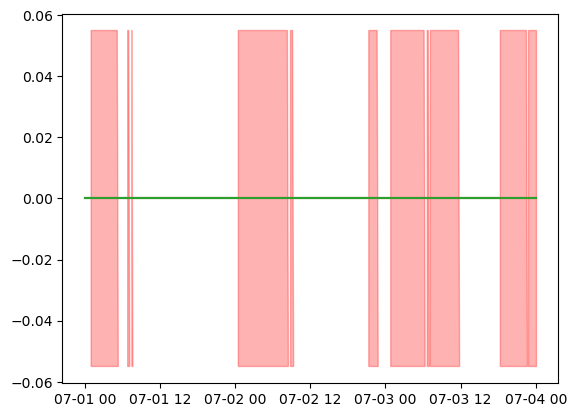

In [12]:
plt.plot(time,f_arr[0])
plt.plot(time,f_arr[1])
plt.plot(time,f_arr[2])
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.2).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.show()

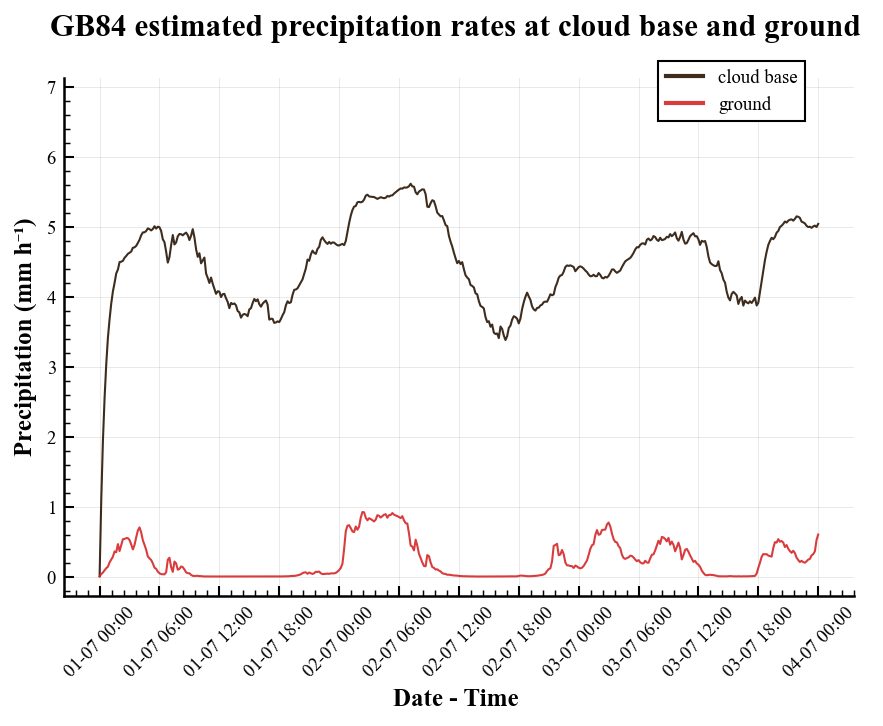

In [35]:
from GB84 import alpha, epsilon_4
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, ScalarFormatter
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 9,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(6, 5))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
##ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, X[0]*4/Z_c_arr[0]*O_b_arr[0]*3600, 
                color=colors['updraft'], 
                linestyle='-', 
                linewidth=1.0,
                label='cloud base',
                alpha=0.9)

# Plot updraft velocity on right axis (ax2)
line4 = ax1.plot(time, P[0]*3600, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='ground',
                alpha=0.9)
#ax1.hlines(y=np.min(X[mask]), xmin=time[mask].min(), xmax=time[mask].max(),)
# Set updraft velocity y-axis to start from 0 and leave space at top

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()


ax1_range = ax1_ylim[1] - ax1_ylim[0]


ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)


# ADD PRECIPITATION SHADING HERE
# Get updated y-limits after extension for proper shading
y_min, y_max = ax1.get_ylim()

# Add red shaded areas for precipitation
# Assuming you have P*3600 and rain_rate variables
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)


# Optionally add shading for actual rain rate with different color/alpha
#ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 #alpha=0.2, color='orange', label='Rain rate > 0.2 mm/h', interpolate=True)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Precipitation (mm h⁻¹)', color='black', fontweight='bold')
ax1.set_title('GB84 estimated precipitation rates at cloud base and ground ', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')


# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)

# Professional y-axis formatting for ax2
#ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#ax2.yaxis.get_offset_text().set_fontsize(11)

# Proper time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# Combine legends from both axes AND precipitation shading
lines1, labels1 = ax1.get_legend_handles_labels()


# Scientific legend positioning
legend = ax1.legend(lines1 , labels1,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1.05),
                   ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

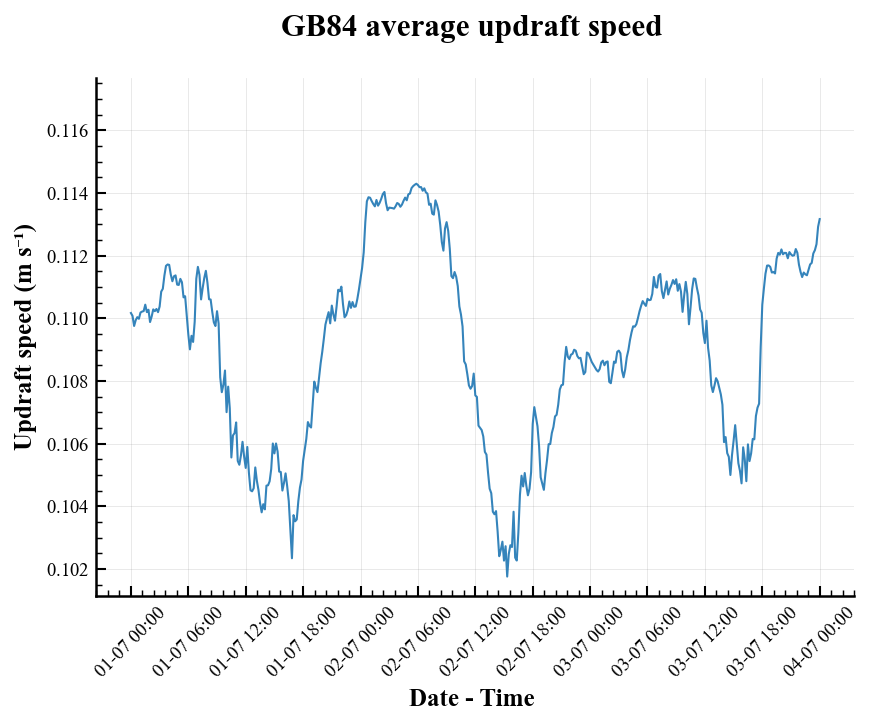

In [41]:
from GB84 import alpha, epsilon_4
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, ScalarFormatter
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 9,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(6, 5))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
##ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, v_arr[0], 
                color=colors['inflow'], 
                linestyle='-', 
                linewidth=1.0,
                label='cloud base',
                alpha=0.9)

#ax1.hlines(y=np.min(X[mask]), xmin=time[mask].min(), xmax=time[mask].max(),)
# Set updraft velocity y-axis to start from 0 and leave space at top

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()


ax1_range = ax1_ylim[1] - ax1_ylim[0]


ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)


# ADD PRECIPITATION SHADING HERE
# Get updated y-limits after extension for proper shading
y_min, y_max = ax1.get_ylim()

# Add red shaded areas for precipitation
# Assuming you have P*3600 and rain_rate variables
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)


# Optionally add shading for actual rain rate with different color/alpha
#ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 #alpha=0.2, color='orange', label='Rain rate > 0.2 mm/h', interpolate=True)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Updraft speed (m s⁻¹)', color='black', fontweight='bold')
ax1.set_title('GB84 average updraft speed ', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')


# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)

# Professional y-axis formatting for ax2
#ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#ax2.yaxis.get_offset_text().set_fontsize(11)

# Proper time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# Combine legends from both axes AND precipitation shading
lines1, labels1 = ax1.get_legend_handles_labels()




# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

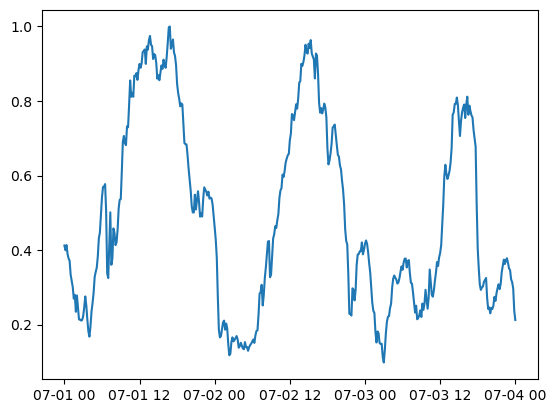

In [14]:
outflow = X[0]*4/Z_c_arr[0]*O_b_arr[0]

#plt.plot(time,outflow/max(outflow))
plt.plot(time,D_c_arr[0]/D_c_arr[0].max())
#plt.plot(time,P[0]/P[0].max())
plt.show()

In [15]:
print(np.mean(Z_c_arr[0]),np.mean(Z_c_arr[1]),np.mean(Z_c_arr[2]))

5530.890269746618 5679.426247497662 5383.9668658572455


In [16]:
print(np.mean(T_m_arr[0]),np.mean(T_m_arr[1]),np.mean(T_m_arr[2]))

276.9059500039346 278.07774329879476 275.74492036674724


In [17]:
print(np.mean(v_arr[0]),np.mean(v_arr[1]),np.mean(v_arr[2]))

0.10906150965846548 0.11083065904237481 0.10725822620559608


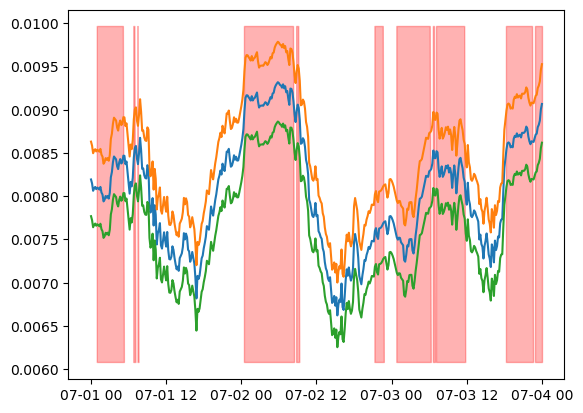

In [18]:
plt.plot(time,ql_total[0])
plt.plot(time,ql_total[1])
plt.plot(time,ql_total[2])
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.2).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.show()

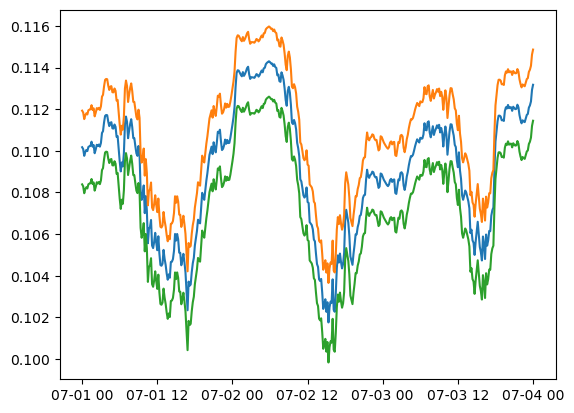

In [19]:
plt.plot(time,v_arr[0])
plt.plot(time,v_arr[1])
plt.plot(time,v_arr[2])
plt.show()

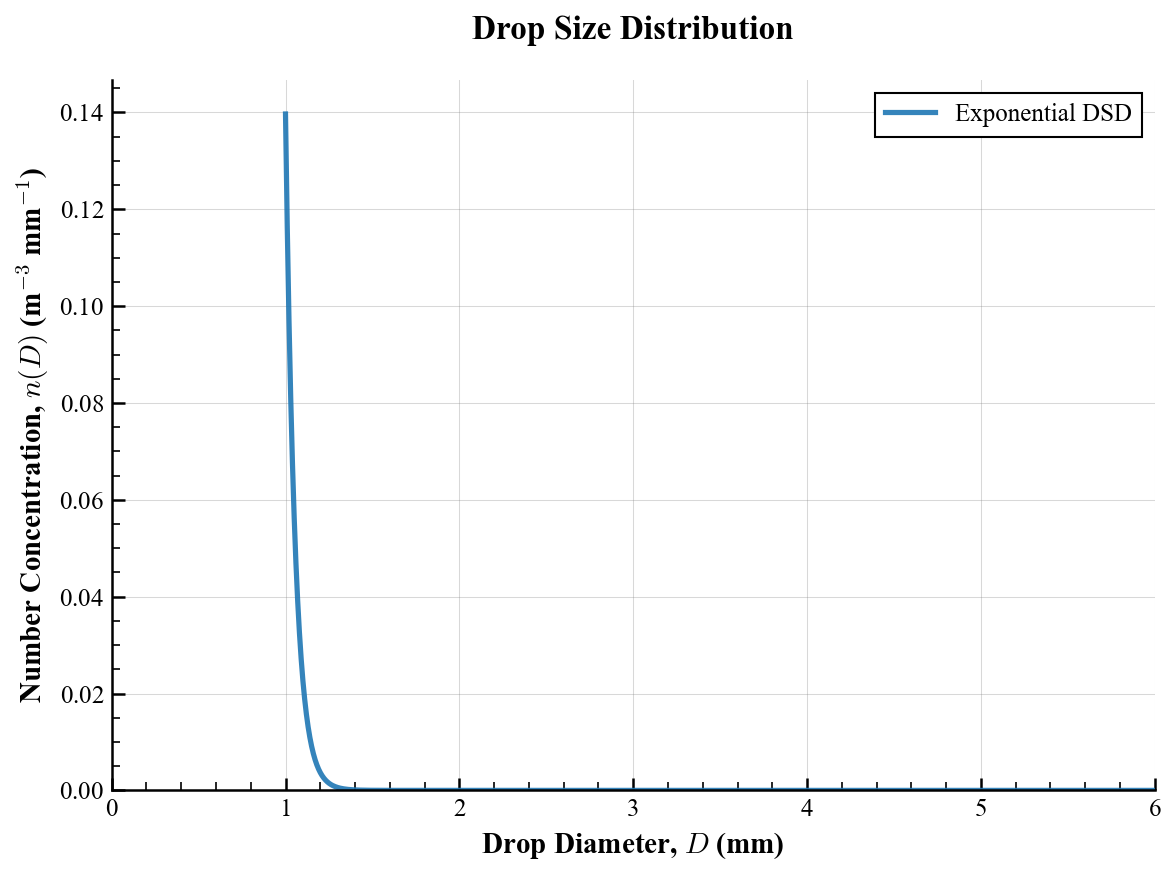

In [20]:
# Set publication-quality style
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 4,
    'ytick.major.size': 6,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.major.width': 1.2,
    'ytick.minor.width': 0.8,
    
    # Legend
    'legend.fontsize': 12,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})


D = np.linspace(1/1000,6/1000,1000)
n_d = (1/(5.5*10**(-5)))**4/(np.pi*Z_c_arr[0,100]*1000)*np.exp(-D/(5.5*10**(-5)))*X[0,100]
D_min = v_arr[0,100]/3500

fig, ax = plt.subplots(figsize=(8, 6))

# Main plot line
line = ax.plot(D * 1000, n_d / 1000, 
               color='#1f77b4',  # Professional blue
               linewidth=2.5,
               label='Exponential DSD',
               alpha=0.9)

# Optional: Add D_min vertical line

# Scientific axis labels with proper units and formatting
ax.set_xlabel('Drop Diameter, $D$ (mm)', fontweight='bold')
ax.set_ylabel('Number Concentration, $n(D)$ (m$^{-3}$ mm$^{-1}$)', fontweight='bold')

# Professional title
ax.set_title('Drop Size Distribution', fontweight='bold', pad=20)

# Scientific grid
ax.grid(True, alpha=0.3, linewidth=0.5, color='gray', linestyle='-')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Professional axis formatting
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# Set appropriate axis limits
ax.set_xlim(left=0, right=6)
ax.set_ylim(bottom=0)

# Add scientific notation to y-axis if needed
ax.yaxis.get_offset_text().set_fontsize(12)

# Professional legend
if 'D_min' in locals():
    legend = ax.legend(loc='upper right',
                      frameon=True,
                      framealpha=1.0,
                      edgecolor='black',
                      facecolor='white',
                      borderaxespad=0.5)
    
    # Set legend line width
    for line in legend.get_lines():
        line.set_linewidth(2.5)

props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.9)


# Ensure proper spacing
plt.tight_layout()

# Display
plt.show()

# Reset rcParams for other plots
plt.rcParams.update(plt.rcParamsDefault)

In [21]:
n_d

array([1.39685300e+02, 1.27535142e+02, 1.16441832e+02, 1.06313446e+02,
       9.70660500e+01, 8.86230147e+01, 8.09143746e+01, 7.38762504e+01,
       6.74503189e+01, 6.15833301e+01, 5.62266660e+01, 5.13359372e+01,
       4.68706156e+01, 4.27936983e+01, 3.90714009e+01, 3.56728778e+01,
       3.25699662e+01, 2.97369533e+01, 2.71503626e+01, 2.47887596e+01,
       2.26325745e+01, 2.06639395e+01, 1.88665410e+01, 1.72254845e+01,
       1.57271710e+01, 1.43591844e+01, 1.31101885e+01, 1.19698332e+01,
       1.09286687e+01, 9.97806715e+00, 9.11015120e+00, 8.31772864e+00,
       7.59423287e+00, 6.93366848e+00, 6.33056155e+00, 5.77991429e+00,
       5.27716363e+00, 4.81814342e+00, 4.39904988e+00, 4.01641008e+00,
       3.66705321e+00, 3.34808422e+00, 3.05685991e+00, 2.79096698e+00,
       2.54820206e+00, 2.32655340e+00, 2.12418426e+00, 1.93941768e+00,
       1.77072253e+00, 1.61670088e+00, 1.47607640e+00, 1.34768378e+00,
       1.23045904e+00, 1.12343080e+00, 1.02571212e+00, 9.36493248e-01,
      

In [22]:
n_d

array([1.39685300e+02, 1.27535142e+02, 1.16441832e+02, 1.06313446e+02,
       9.70660500e+01, 8.86230147e+01, 8.09143746e+01, 7.38762504e+01,
       6.74503189e+01, 6.15833301e+01, 5.62266660e+01, 5.13359372e+01,
       4.68706156e+01, 4.27936983e+01, 3.90714009e+01, 3.56728778e+01,
       3.25699662e+01, 2.97369533e+01, 2.71503626e+01, 2.47887596e+01,
       2.26325745e+01, 2.06639395e+01, 1.88665410e+01, 1.72254845e+01,
       1.57271710e+01, 1.43591844e+01, 1.31101885e+01, 1.19698332e+01,
       1.09286687e+01, 9.97806715e+00, 9.11015120e+00, 8.31772864e+00,
       7.59423287e+00, 6.93366848e+00, 6.33056155e+00, 5.77991429e+00,
       5.27716363e+00, 4.81814342e+00, 4.39904988e+00, 4.01641008e+00,
       3.66705321e+00, 3.34808422e+00, 3.05685991e+00, 2.79096698e+00,
       2.54820206e+00, 2.32655340e+00, 2.12418426e+00, 1.93941768e+00,
       1.77072253e+00, 1.61670088e+00, 1.47607640e+00, 1.34768378e+00,
       1.23045904e+00, 1.12343080e+00, 1.02571212e+00, 9.36493248e-01,
      

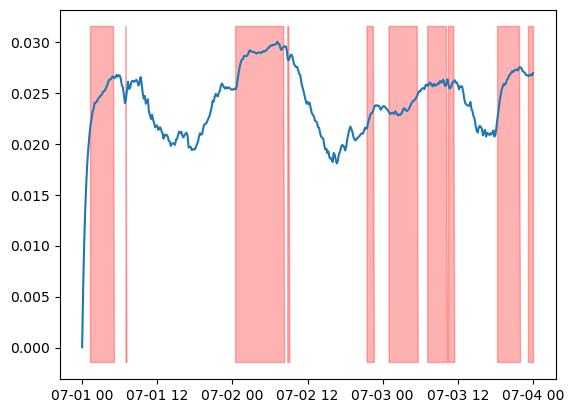

In [23]:
plt.plot(time,O_b_arr[0]*4*3500*5.5/1000/Z_c_arr[0]*X[0])
#plt.plot(time,O_b_arr[1]*X[1])
#plt.plot(time,O_b_arr[2]*X[2])
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
#plt.plot(time,P[0]*3600,color='blue')
#plt.plot(time,P[1]*3600,color='orange')
#plt.plot(time,P[2]*3600,color='green') 
plt.show()  

In [24]:
from GB84 import w

In [25]:
w(T_d,p_0) - w(T_t,p_t)

np.float64(0.008619258512227761)

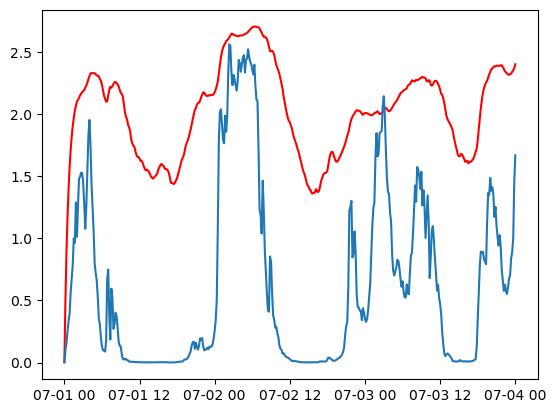

In [26]:
#plt.plot(time,D_c_arr[0]*3600,color='blue')
plt.plot(time,X[0],color='red')
#plt.plot(time,D_c_arr[1]*3600,color='orange')
#plt.plot(time,D_c_arr[2]*3600,color='green') 
plt.plot(time,P[0]*10000)
#plt.plot(time,P[1]*3600,color='orange')
#plt.plot(time,P[2]*3600,color='green') 
plt.show()  

### Plots and results

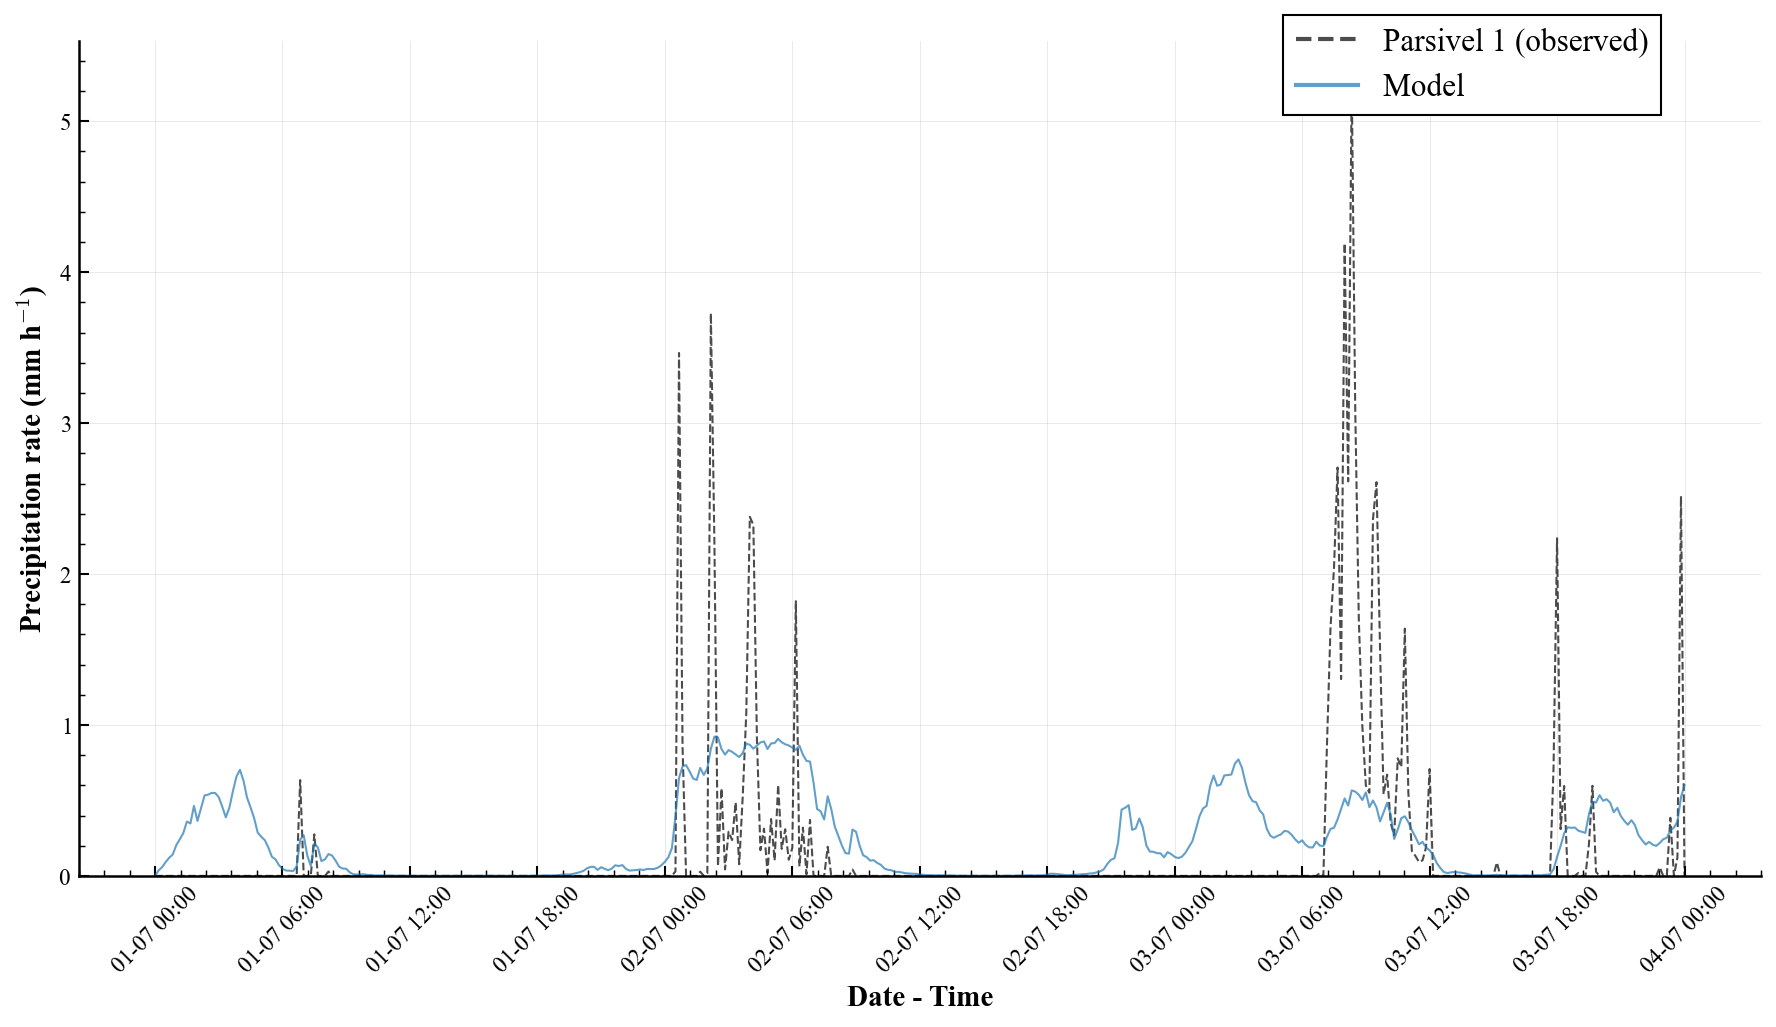

In [27]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 20,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 15,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import numpy as np

# Create figure
plt.figure(figsize=(12, 7))

# Scientific color palette (colorblind-friendly) - matching your style
colors = {
    'observed': '#000000',      # Black
    'model_1': '#1f77b4',      # Blue
    'model_2': '#ff7f0e',      # Orange
    'threshold': "#675AA0"     # Red for threshold
}

# Plot precipitation data
plt.plot(rain_rate.time,rain_rate, 
         label='Parsivel 1 (observed)', 
         color=colors['observed'], 
         alpha=0.7,
         linestyle='--',
         linewidth=1.0)

plt.plot(time, P[0] * 3600, 
         label='Model ', 
         color=colors['model_1'], 
         alpha=0.7,
         linewidth=1.0)

# Add precipitation threshold line for reference
threshold = 0.25  # mm/h
#plt.axhline(y=threshold, color=colors['threshold'], 
           #linestyle=':', alpha=0.7, linewidth=1.5,
           #label=f'Threshold ({threshold} mm h$^{{-1}}$)')

# Enhanced axis formatting - matching your style
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Proper time axis formatting (matching your existing code)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45)
    plt.xlabel('Date - Time', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    plt.xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    plt.gca().xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    plt.xlim(left=0)

# Scientific axis labels with proper units - matching your style
plt.ylabel('Precipitation rate (mm h$^{-1}$)', fontweight='bold')
#plt.title('Precipitation Rate Comparison', 
          #fontweight='bold', pad=20)

# Set y-axis to start from 0
plt.ylim(bottom=0)

# Scientific grid (matching your style)
plt.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
plt.gca().set_axisbelow(True)

# Minor ticks for precision (matching your style)
plt.gca().minorticks_on()

# Professional y-axis formatting (matching your style)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().yaxis.get_offset_text().set_fontsize(11)

# Scientific legend positioning (matching your style)
legend = plt.legend(loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1.05),
                   ncol=1)

# Set legend line width to match plot lines (matching your style)
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)


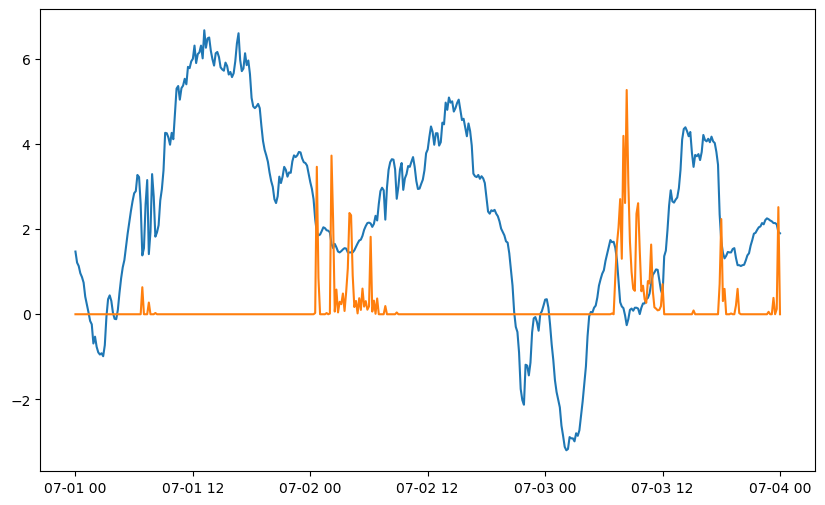

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(time, T_surf - T_d)
plt.plot(time,rain_rate)
plt.show()

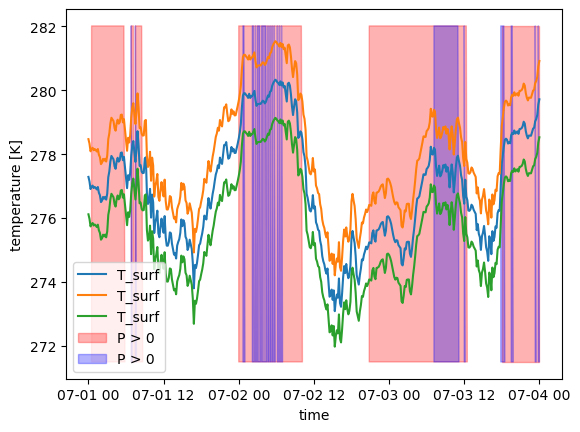

In [29]:

plt.plot(time, T_m_arr[0], label='T_surf')
plt.plot(time, T_m_arr[1], label='T_surf')
plt.plot(time, T_m_arr[2], label='T_surf')
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[1]*3600 > 0.2).values if hasattr(P[1]*3600, 'values') else (P[1]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

In [30]:
time_mask = np.where(P*3600 > 0.2)
time_actual = rain_rate.time[np.where(rain_rate > 0.2)]
plt.figure(figsize=(10,6))
plt.plot(time, T_surf -T_d_arr, label='T_surf')
#plt.plot(time, T_d_arr, label='T_d')

# Get y-axis limits after plotting
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (433,) and (3, 433)

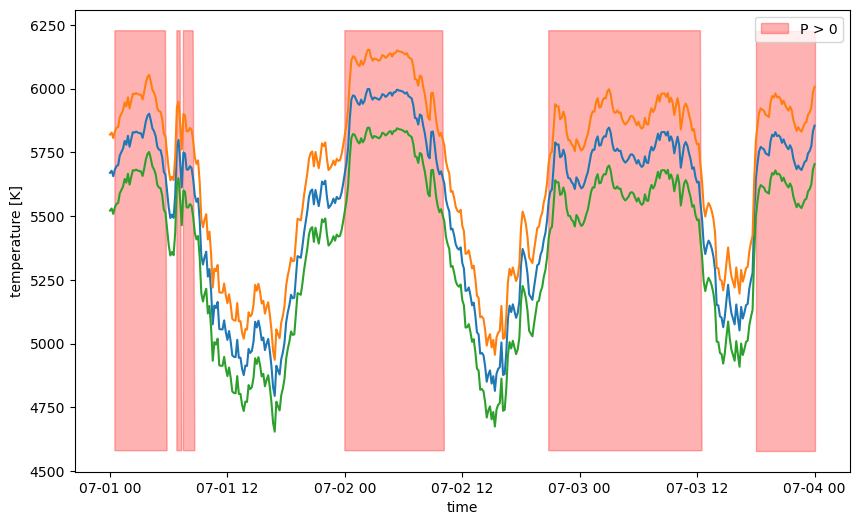

In [ ]:
#plt.plot(time,Z_b_arr[0])
#plt.plot(time,Z_b_arr[1])
#plt.plot(time,Z_b_arr[2])
plt.plot(time,Z_c_arr[0])
plt.plot(time,Z_c_arr[1])
plt.plot(time,Z_c_arr[2])
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[1]*3600 > 0.2).values if hasattr(P[1]*3600, 'values') else (P[1]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()


In [ ]:
np.mean(Z_c_arr[0][mask] - Z_c_arr[1][mask])

-150.97364927257883

In [ ]:
np.mean(f_arr[0][mask] - f_arr[1][mask])*3600

0.0

In [ ]:
w(T_d,p_surf)

array([0.00944518, 0.00944518, 0.00944425, 0.00944425, 0.00944425,
       0.00944425, 0.00944331, 0.00944331, 0.00944331, 0.00944331,
       0.00944331, 0.00944331, 0.00944331, 0.00944331, 0.00944331,
       0.00944331, 0.00944331, 0.00944331, 0.00944331, 0.00944238,
       0.00944145, 0.00944145, 0.00944145, 0.00944052, 0.00944052,
       0.00943959, 0.00943959, 0.00943959, 0.00943959, 0.00943959,
       0.00943959, 0.00943866, 0.00943773, 0.0094368 , 0.00943587,
       0.00943587, 0.00943587, 0.00943401, 0.00943308, 0.00943215,
       0.00943215, 0.00943122, 0.00943029, 0.00943029, 0.00943029,
       0.00942844, 0.00942936, 0.00942844, 0.00942658, 0.00942565,
       0.00942472, 0.00942565, 0.00942472, 0.00942472, 0.00942472,
       0.00942565, 0.00942565, 0.00942565, 0.00942472, 0.0094238 ,
       0.00942287, 0.00942287, 0.00942287, 0.00942287, 0.00942287,
       0.00942287, 0.00942287, 0.00942287, 0.00942194, 0.00942194,
       0.00942194, 0.00942102, 0.00942009, 0.00942009, 0.00941

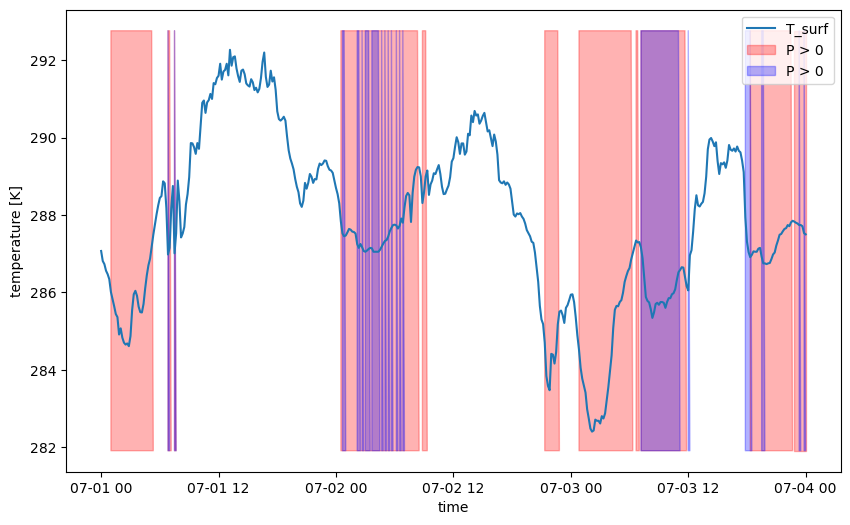

In [ ]:
time_mask = np.where(P*3600 > 0.2)
time_actual = rain_rate.time[np.where(rain_rate > 0.2)]
plt.figure(figsize=(10,6))
plt.plot(time, T_surf, label='T_surf')
#plt.plot(time, T_d_arr, label='T_d')

# Get y-axis limits after plotting
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.2).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

In [ ]:
time_mask = np.where(P*3600 > 0.2)
time_actual = rain_rate.time[np.where(rain_rate > 0.2)]
plt.figure(figsize=(10,6))
plt.plot(time, Z_b_arr, label='T_surf')
#plt.plot(time, T_d_arr, label='T_d')

# Get y-axis limits after plotting
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (433,) and (3, 433)

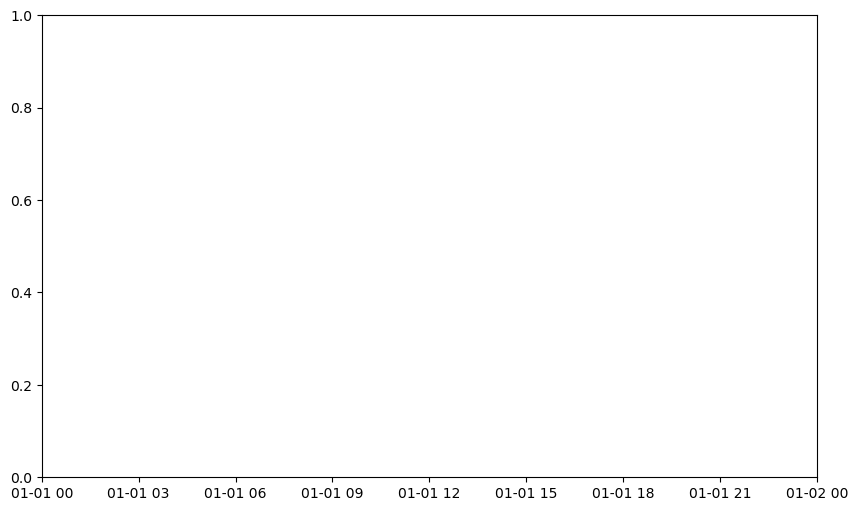

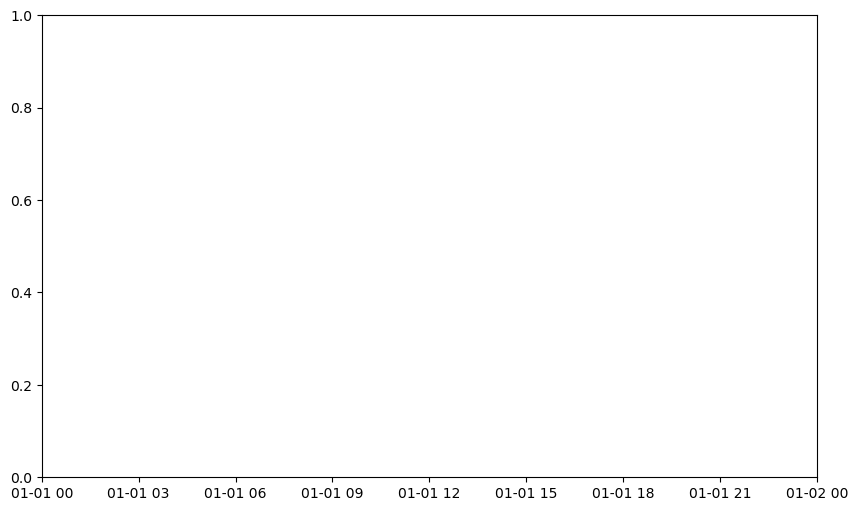

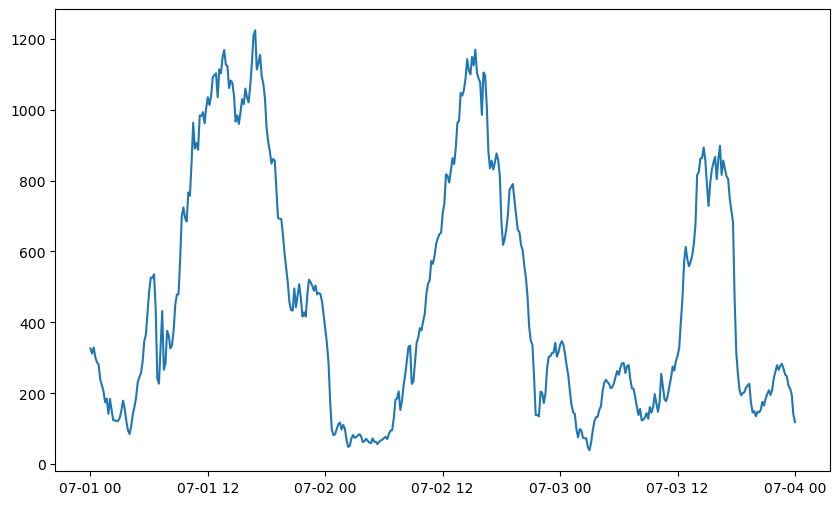

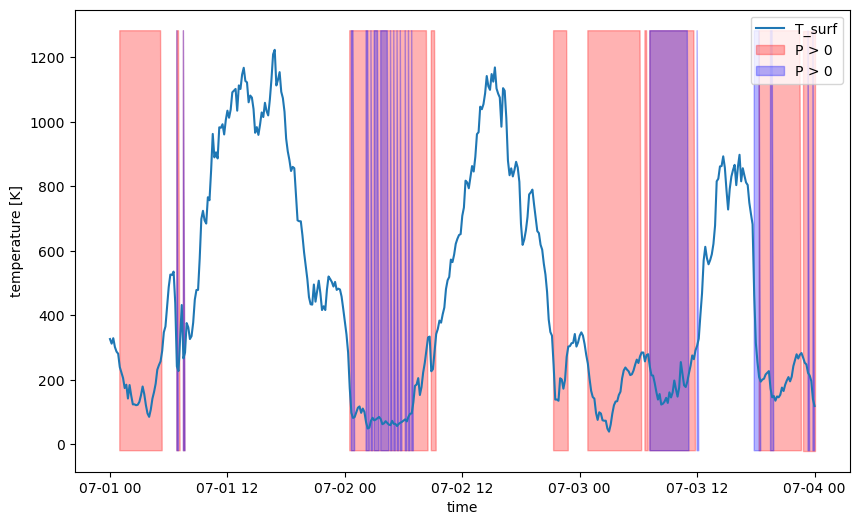

In [ ]:
time_mask = np.where(P*3600 > 0.2)
time_actual = rain_rate.time[np.where(rain_rate > 0.2)]
plt.figure(figsize=(10,6))
plt.plot(time, Z_b_arr[0], label='T_surf')
#plt.plot(time, T_d_arr, label='T_d')

# Get y-axis limits after plotting
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.2).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

In [ ]:
sensitivity_temp_diff = (np.diff(P[mask])/(P[mask])[:-1])/((np.diff(T_surf[mask] -T_d_arr[mask])/(T_surf[mask] -T_d_arr[mask])[:-1]))


sensitivity_temp = (np.diff(P[mask])/(P[mask])[:-1])/((np.maximum(1,np.diff(T_surf[mask]))/(T_surf[mask])[:-1]))

print(np.mean(sensitivity_temp_diff),np.mean(sensitivity_temp))

IndexError: boolean index did not match indexed array along dimension 0; dimension is 3 but corresponding boolean dimension is 433

In [ ]:
np.diff(T_surf[mask])

array([-0.1800232 , -0.19000244, -0.19998169, -0.08001709, -0.4499817 ,
        0.16000366, -0.24002075, -0.13000488, -0.04998779,  0.02999878,
       -0.07000732,  0.26000977,  0.6699829 ,  0.41000366,  0.09002686,
       -0.13000488, -0.27999878, -0.14001465, -0.01000977,  0.22000122,
        0.4000244 ,  0.33999634,  0.25997925,  0.17001343,  0.32000732,
       -0.21002197,  0.17001343, -0.14001465,  0.8200073 , -0.30999756,
       -0.07000732,  0.02001953,  0.07998657,  0.08999634, -0.01998901,
       -0.04998779, -0.01000977, -0.04000854, -0.269989  , -0.1000061 ,
        0.1000061 , -0.08001709, -0.09997559, -0.02001953,  0.02999878,
        0.04000854,  0.02999878, -0.01000977, -0.08999634,  0.        ,
        0.        ,  0.        ,  0.05001831,  0.07998657,  0.07998657,
        0.07000732,  0.02001953,  0.08999634,  0.13998413,  0.08999634,
        0.07000732,  0.01000977, -0.02001953, -0.07998657,  0.07000732,
        0.19000244, -0.11001587,  0.39001465,  0.2999878 ,  0.08

In [ ]:
np.mean(T_surf[~mask] -T_d_arr[~mask])

5.3715277

In [ ]:
grd = np.gradient(P*3600,T_surf)
plt.plot(time,grd)
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.show()

TypeError: invalid number of arguments

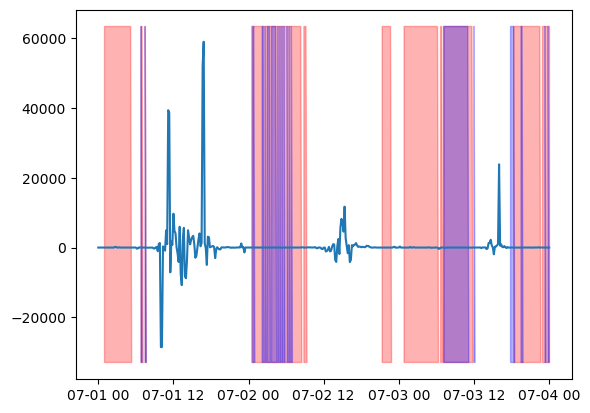

In [ ]:
grd_2 = np.gradient(T_d_arr,P*3600)
plt.plot(time,grd_2)
y_min, y_max = plt.ylim()
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)

plt.show()

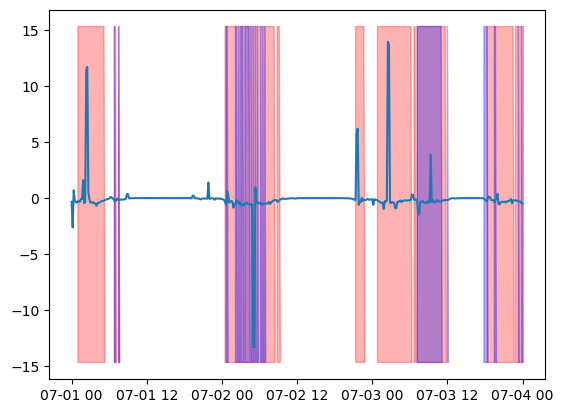

In [ ]:
grd_2 = np.gradient(P*3600,T_surf -T_d_arr)
plt.plot(time,grd_2)
y_min, y_max = plt.ylim()
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                alpha=0.3, color='blue', label='P > 0', interpolate=True)

plt.show()

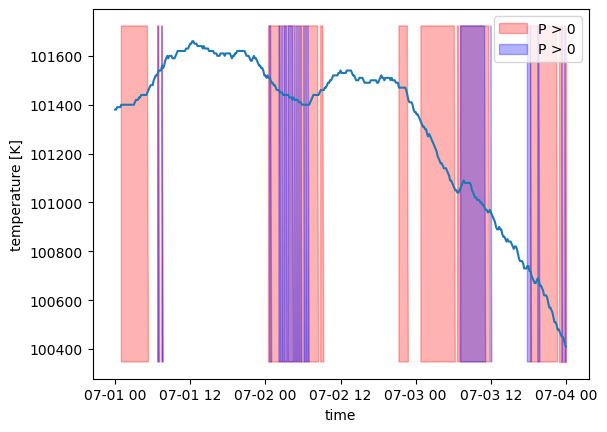

In [ ]:
plt.plot(time,p_surf)
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()
plt.show()

In [ ]:
np.mean((p_s-p_surf)[time_mask])

-2173.2456

In [ ]:
np.mean((p_s-p_surf))

-2315.0242

In [ ]:
np.mean(T_d_arr)

284.3204

In [ ]:
np.mean(T_d_arr[time_mask])

285.0325

In [ ]:
print(np.mean(T_surf), np.mean(T_surf[time_mask]))

287.9184 286.27542


In [ ]:
time_mask

(array([  6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
         19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
         41,  42,  45, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
        157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
        170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
        183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 197,
        198, 199, 272, 273, 274, 275, 276, 277, 278, 279, 280, 293, 294,
        295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307,
        308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320,
        321, 322, 323, 324, 325, 328, 329, 331, 332, 333, 334, 335, 336,
        337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349,
        350, 351, 352, 353, 354, 355, 356, 357, 358, 398, 399, 400, 401,
        402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414,
        415, 416, 417, 418, 419, 420, 421, 422, 423

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

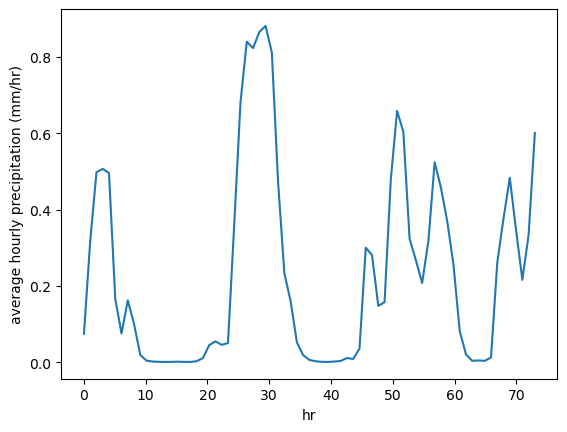

In [ ]:
Pmeas = rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

## Result analysis

In [ ]:
count_prec = np.sum((rain_rate>0.38) & (P*3600 > 0.25))
count_no_prec = np.sum((rain_rate==0) & (P*3600<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (P * 3600 < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (P*3600 > 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (P*3600 > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (P*3600 < 0.25))

ValueError: dimensions ('time',) must have the same length as the number of data dimensions, ndim=2

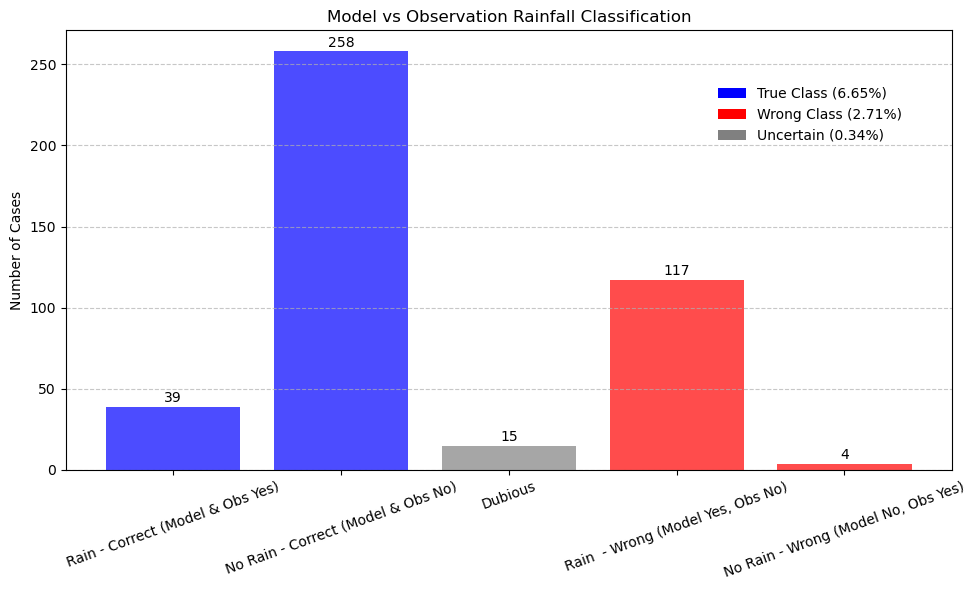

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


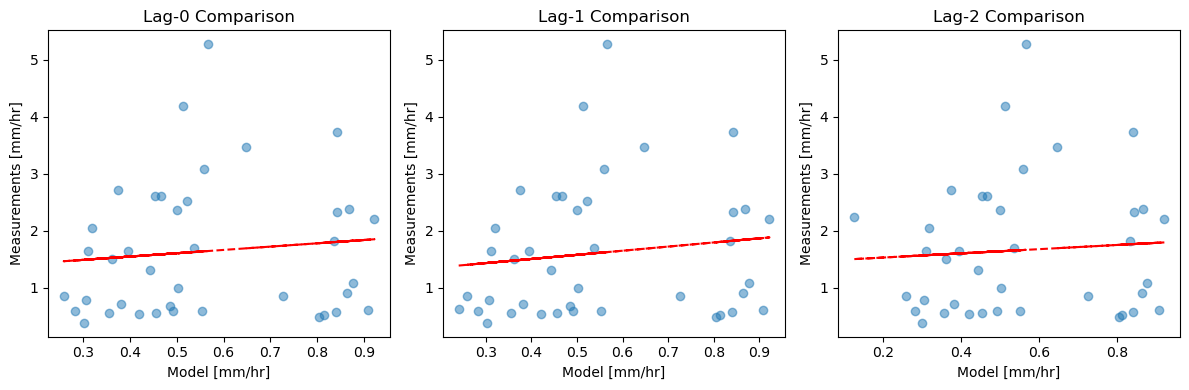

In [ ]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')

# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')

# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

#plt.ylim(0,10)

In [ ]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

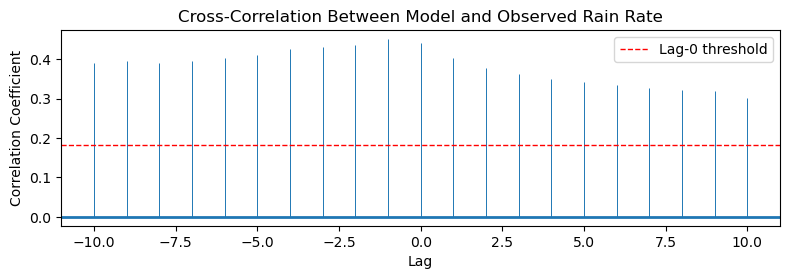

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

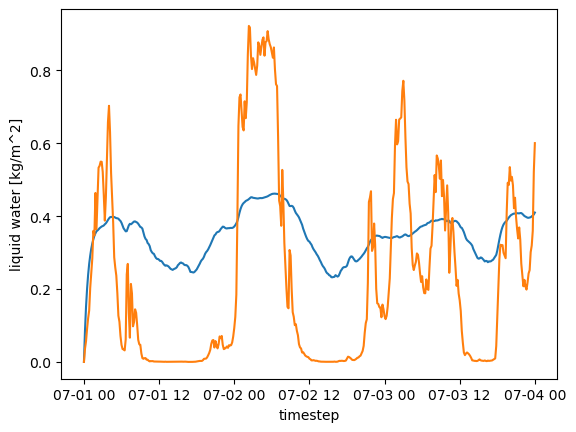

In [ ]:
#state evolution

plt.plot(measurements_used.time,X/Z_c*1000)
plt.plot(measurements_used.time,P*3600)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

In [ ]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))
p_t_arr = np.zeros(len(T_surf))
Z_b_arr = np.zeros(len(T_surf))
T_t_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    p_t_arr[i] = p_t
    T_t_arr[i] = T_t
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    Z_b_arr[i] = Z_b
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


KeyboardInterrupt: 

In [ ]:
from GB84 import w

print(np.mean(w(T_d_arr,p_surf)), np.mean(w(T_d_arr,p_surf)[time_mask]))

0.008815182 0.009193182


In [ ]:
# Publication-quality Cloud Fluxes Plot
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import pandas as pd

# Publication styling
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Scientific color palette
colors = {
    'updraft': '#1f77b4',  # Blue
    'zero_line': '#808080'  # Gray for zero reference
}

# Plot updraft velocity
line1 = ax.plot(time, Z_c_arr,
                color=colors['updraft'],
                linestyle='-',
                linewidth=2.0,
                alpha=0.9)

# Add zero reference line
#ax.axhline(y=0, color=colors['zero_line'], linestyle='--', linewidth=1.0, alpha=0.7)

# Scientific axis labels with proper units
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel('Cloud depth [m]', fontweight='bold')
ax.set_title('Cloud depth evolution in time', fontweight='bold', pad=20)

# Scientific grid
ax.grid(True, alpha=0.3, linewidth=0.7, color='gray', linestyle='-')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Professional y-axis formatting
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Proper time axis formatting (assuming time is datetime-like)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_xlabel('Date - Time', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    ax.set_xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    ax.xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    ax.set_xlim(left=0)

# Scientific legend positioning (moved higher)
"""
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  bbox_to_anchor=(0.98, 0.98),
                  ncol=1)
"""

# Set legend line width to match plot lines (commented out since legend is commented)
# for line in legend.get_lines():
#     line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

ValueError: x and y must have same first dimension, but have shapes (433,) and (3, 433)

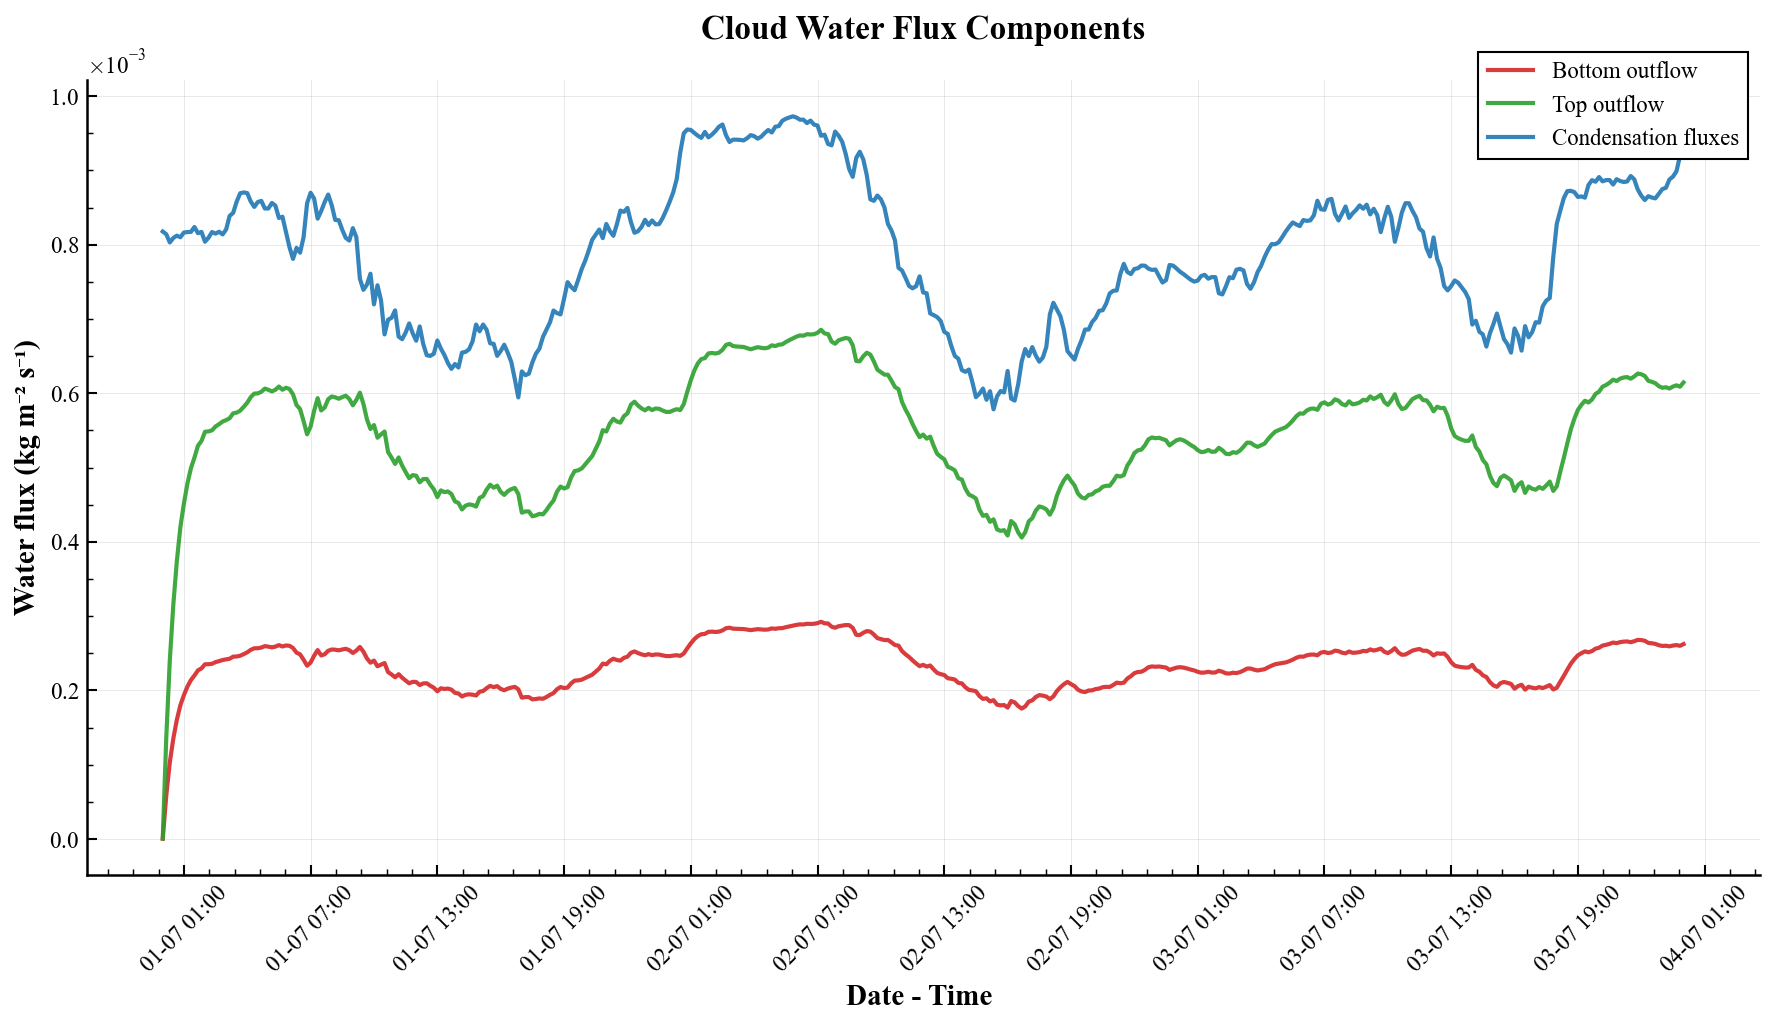

In [ ]:
# Publication-quality Cloud Fluxes Plot
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import pandas as pd

# Publication styling
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'precipitation_model': '#ff7f0e',  # Orange (for shaded areas)
    'precipitation_obs': '#9467bd'      # Purple (for shaded areas)
}

# Plot with scientific line styles and markers
line1 = ax.plot(time, O_b_arr, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=2.0,
                label='Bottom outflow',
                alpha=0.9)

line2 = ax.plot(time, O_h_arr, 
                color=colors['outflow_top'], 
                linestyle='-', 
                linewidth=2.0,
                label='Top outflow',
                alpha=0.9)

line3 = ax.plot(time, I_arr, 
                color=colors['inflow'], 
                linestyle='-', 
                linewidth=2.0,
                label='Condensation fluxes',
                alpha=0.9)

# Get y-axis limits for shaded areas
y_min, y_max = ax.get_ylim()

# Optional: Add precipitation shaded areas (uncomment if needed)
"""
# Handle xarray compatibility
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)

ax.fill_between(time, y_min, y_max, where=mask,
                alpha=0.2, color=colors['precipitation_model'], 
                label='Model precipitation > 0.2 mm h⁻¹', 
                interpolate=True)

ax.fill_between(time, y_min, y_max, where=mask_actual,
                alpha=0.2, color=colors['precipitation_obs'], 
                label='Observed precipitation > 0.2 mm h⁻¹', 
                interpolate=True)
"""

# Scientific axis labels with proper units
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel('Water flux (kg m⁻² s⁻¹)', fontweight='bold')
ax.set_title('Cloud Water Flux Components', fontweight='bold', pad=20)

# Scientific grid
ax.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Professional y-axis formatting with scientific notation at top
#ax.ticklabel_format(style='scientific', axis='y', scilimits=(-3, -3))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
ax.set_ylabel('Water flux (kg m⁻² s⁻¹)', fontweight='bold')
# Alternative method to explicitly set the scale
ax.yaxis.get_major_formatter().set_powerlimits((-3, -3))

# Proper time axis formatting (assuming time is datetime-like)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_xlabel('Date - Time ', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes
    ax.set_xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours
    ax.xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes

# Scientific legend positioning
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5,  # Reduced padding
                  bbox_to_anchor=(1.0, 1.05),  # Explicitly position at top-right corner
                  ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Add subtle background
#ax.set_facecolor('#fafafa')

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Optional: Add annotations for key features
"""
# Example: Mark maximum values
max_bottom = np.max(O_b_arr)
max_top = np.max(O_h_arr)
max_inflow = np.max(I_arr)

ax.annotate(f'Max: {max_bottom:.2e}', 
           xy=(time[np.argmax(O_b_arr)], max_bottom),
           xytext=(10, 10), textcoords='offset points',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
"""

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save the figure
# plt.savefig('cloud_fluxes_publication.pdf', dpi=300, bbox_inches='tight')

# Optional: Save the figure
# plt.savefig('cloud_fluxes_publication.pdf', dpi=300, bbox_inches='tight')

# Optional: Save the figure
# plt.savefig('cloud_fluxes_publication.pdf', dpi=300, bbox_inches=

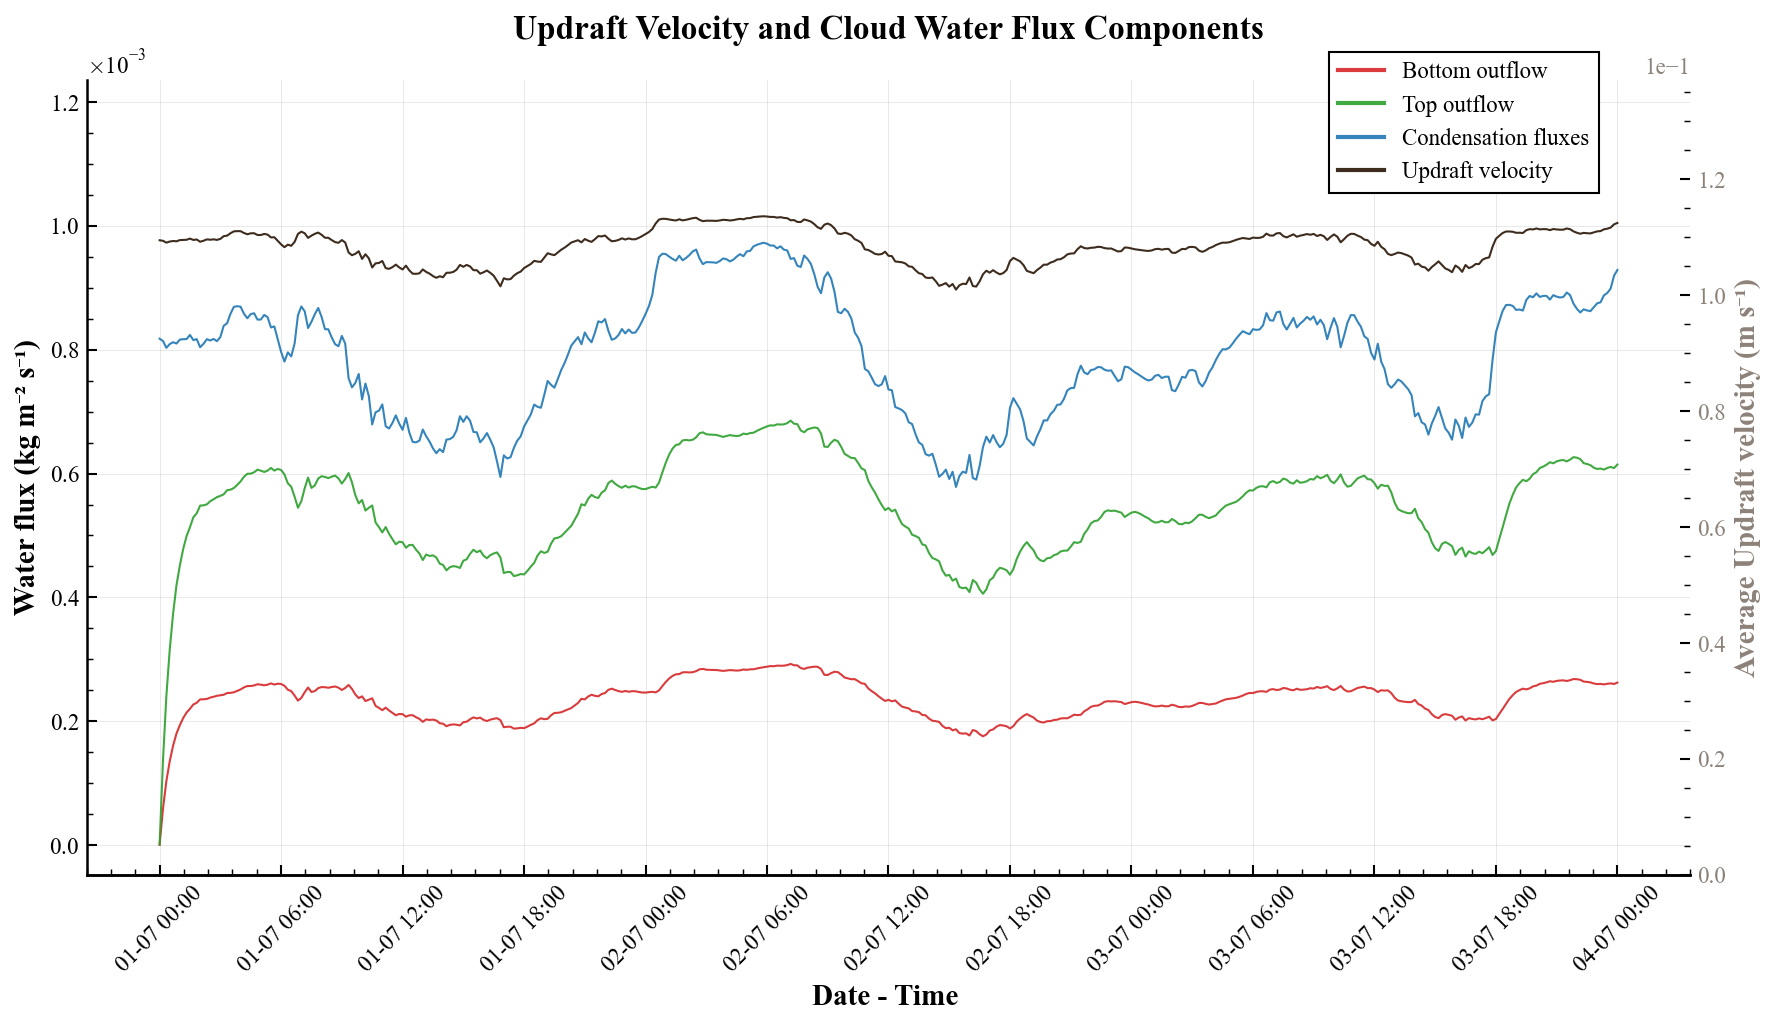

In [ ]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, O_b_arr, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='Bottom outflow',
                alpha=0.9)

line2 = ax1.plot(time, O_h_arr, 
                color=colors['outflow_top'], 
                linestyle='-', 
                linewidth=1.0,
                label='Top outflow',
                alpha=0.9)

line3 = ax1.plot(time, I_arr, 
                color=colors['inflow'], 
                linestyle='-', 
                linewidth=1.0,
                label='Condensation fluxes',
                alpha=0.9)

# Plot updraft velocity on right axis (ax2)
line4 = ax2.plot(time, v_arr, 
                color=colors['updraft'], 
                linestyle='-', 
                linewidth=1.0,
                label='Updraft velocity',
                alpha=0.9)

# Set updraft velocity y-axis to start from 0 and leave space at top
ax2.set_ylim(bottom=0)

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()

ax1_range = ax1_ylim[1] - ax1_ylim[0]
ax2_range = ax2_ylim[1] - ax2_ylim[0]

ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)
ax2.set_ylim(0, ax2_ylim[1] + 0.2 * ax2_range)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Water flux (kg m⁻² s⁻¹)', color='black', fontweight='bold')
ax2.set_ylabel('Average Updraft velocity (m s⁻¹)', color=colors['updraft'], fontweight='bold')
ax1.set_title('Updraft Velocity and Cloud Water Flux Components', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['updraft'])

# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()
ax2.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
ax1.yaxis.get_major_formatter().set_powerlimits((-3, -3))

# Professional y-axis formatting for ax2 (updraft velocity) - force 10^-1 scale
#ax2.ticklabel_format(style='scientific', axis='y', scilimits=(-1, -1))
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax2.yaxis.get_offset_text().set_fontsize(11)
ax2.yaxis.get_major_formatter().set_powerlimits((-1, -1))
#ax.yaxis.set_major_formatter(ScalarFormatter())
# Proper time axis formatting (assuming time is datetime-like)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    ax1.set_xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    ax1.xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    ax1.set_xlim(left=0)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Scientific legend positioning
legend = ax1.legend(lines1 + lines2, labels1 + labels2,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,  # Reduced padding
                   bbox_to_anchor=(0.95, 1.05),  # Explicitly position at top-right corner
                   ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

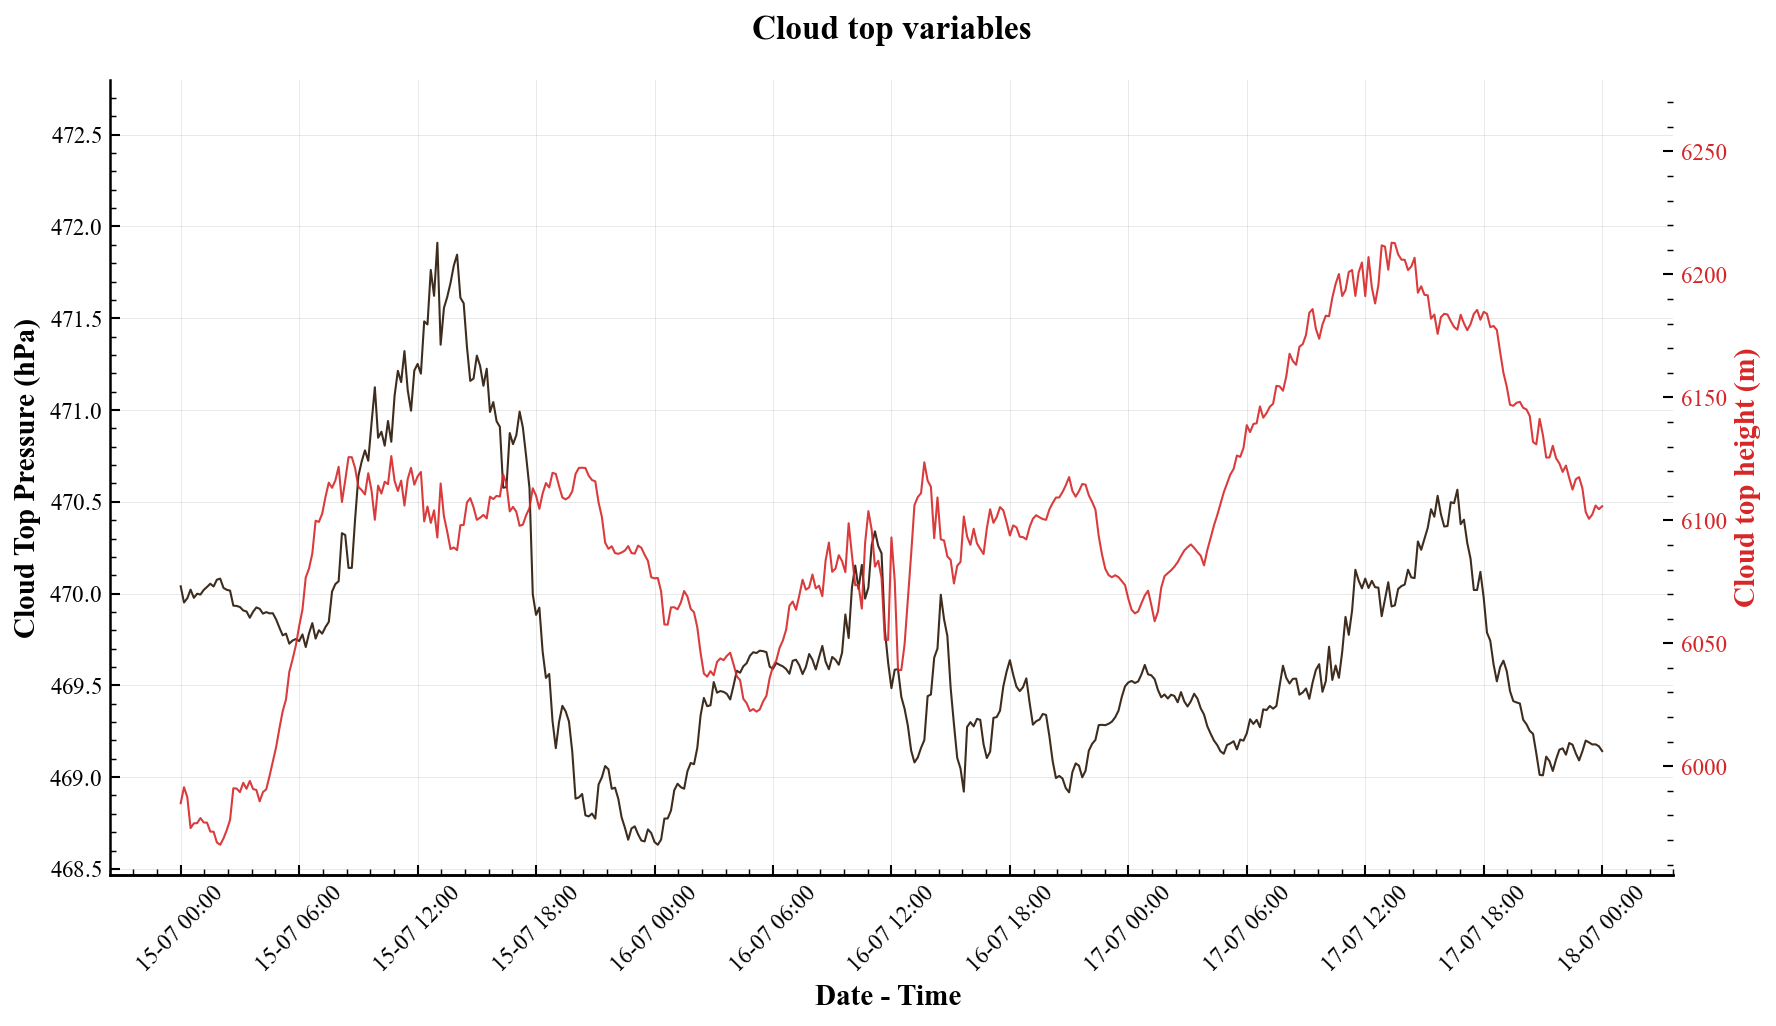

In [ ]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, p_t_arr[0]/100, 
                color=colors['updraft'], 
                linestyle='-', 
                linewidth=1.0,
                label='LWP - Model State',
                alpha=0.9)


# Plot updraft velocity on right axis (ax2)
line4 = ax2.plot(time, Z_c_arr[0] + Z_b_arr[0], 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='LWC',
                alpha=0.9)

# Set updraft velocity y-axis to start from 0 and leave space at top
#ax2.set_ylim(bottom=0)

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()

ax1_range = ax1_ylim[1] - ax1_ylim[0]
ax2_range = ax2_ylim[1] - ax2_ylim[0]

ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)
ax2.set_ylim(ax2_ylim[0], ax2_ylim[1] + 0.2 * ax2_range)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Cloud Top Pressure (hPa)', color='black', fontweight='bold')
ax2.set_ylabel('Cloud top height (m)', color=colors['outflow_bottom'], fontweight='bold')
ax1.set_title('Cloud top variables', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['outflow_bottom'])

# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()
ax2.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
#ax1.yaxis.get_major_formatter().set_powerlimits((-3, -3))

# Professional y-axis formatting for ax2 (updraft velocity) - force 10^-1 scale
#ax2.ticklabel_format(style='scientific', axis='y', scilimits=(-1, -1))
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax2.yaxis.get_offset_text().set_fontsize(11)
#ax2.yaxis.get_major_formatter().set_powerlimits((-1, -1))
#ax.yaxis.set_major_formatter(ScalarFormatter())
# Proper time axis formatting (assuming time is datetime-like)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    ax1.set_xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    ax1.xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    ax1.set_xlim(left=0)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Scientific legend positioning


# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
np.min(Z_c_arr[0] + Z_b_arr[0])

5874.553277658393

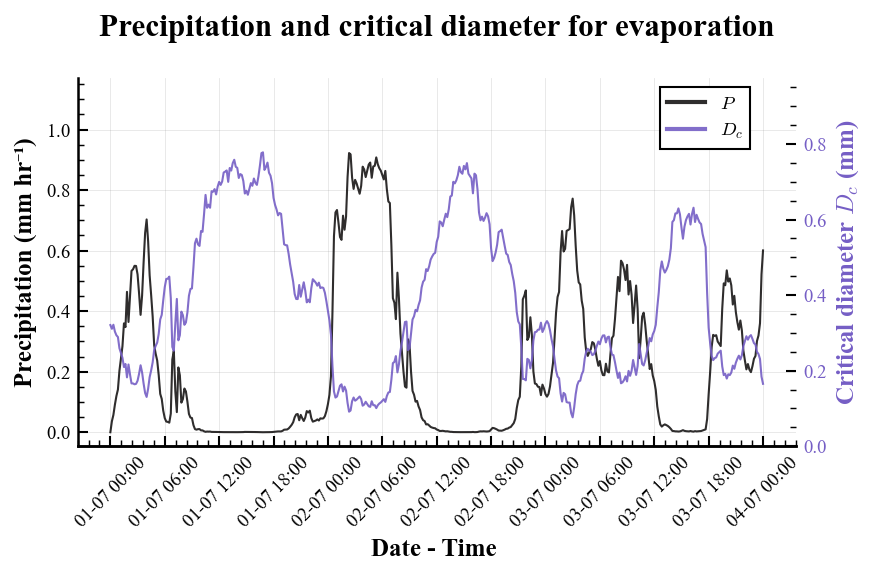

In [33]:
from GB84 import alpha, epsilon_4
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 9,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})


# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': "#755ec5",    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#181616EA",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, P[0]*3600, 
                color=colors['updraft'], 
                linestyle='-', 
                linewidth=1.0,
                label='$P$',
                alpha=0.9)


# Plot updraft velocity on right axis (ax2)
line4 = ax2.plot(time, D_c_arr[0]*1000, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='$D_c$',
                alpha=0.9)

# Set updraft velocity y-axis to start from 0 and leave space at top
ax2.set_ylim(bottom=0)

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()

ax1_range = ax1_ylim[1] - ax1_ylim[0]
ax2_range = ax2_ylim[1] - ax2_ylim[0]

ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)
ax2.set_ylim(0, ax2_ylim[1] + 0.2 * ax2_range)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Precipitation (mm hr⁻¹)', color='black', fontweight='bold')
ax2.set_ylabel('Critical diameter $D_c$ (mm)', color=colors['outflow_bottom'], fontweight='bold')
ax1.set_title('Precipitation and critical diameter for evaporation', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['outflow_bottom'])

# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()
ax2.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
#ax1.yaxis.get_major_formatter().set_powerlimits((-3, -3))

# Professional y-axis formatting for ax2 (updraft velocity) - force 10^-1 scale
#ax2.ticklabel_format(style='scientific', axis='y', scilimits=(-1, -1))
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax2.yaxis.get_offset_text().set_fontsize(11)
#ax2.yaxis.get_major_formatter().set_powerlimits((-1, -1))
#ax.yaxis.set_major_formatter(ScalarFormatter())
# Proper time axis formatting (assuming time is datetime-like)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    ax1.set_xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    ax1.xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    ax1.set_xlim(left=0)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Scientific legend positioning
legend = ax1.legend(lines1 + lines2, labels1 + labels2,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,  # Reduced padding
                   bbox_to_anchor=(0.95, 1),  # Explicitly position at top-right corner
                   ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

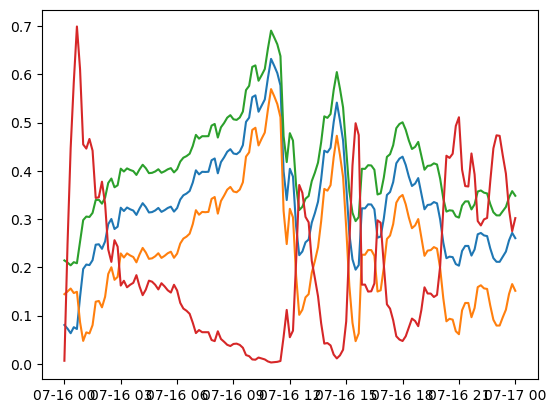

In [ ]:
plt.plot(time,D_c_arr[0]*1000)  
plt.plot(time,D_c_arr[1]*1000)
plt.plot(time,D_c_arr[2]*1000)
plt.plot(time,P[0]*3600)
plt.show()

In [ ]:
import pickle

# Example: bundle the arrays and time into a dict
data_to_save = {
    "time": time,
    "Dc": D_c_arr  # your array with 3 curves
}

# Save to pickle file
with open("Dc_results_Td.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

In [ ]:
with open("Dc_results_T.pkl", "rb") as f:
    loaded = pickle.load(f)

time_loaded = loaded["time"]
D_c_arr_loaded = loaded["Dc"]

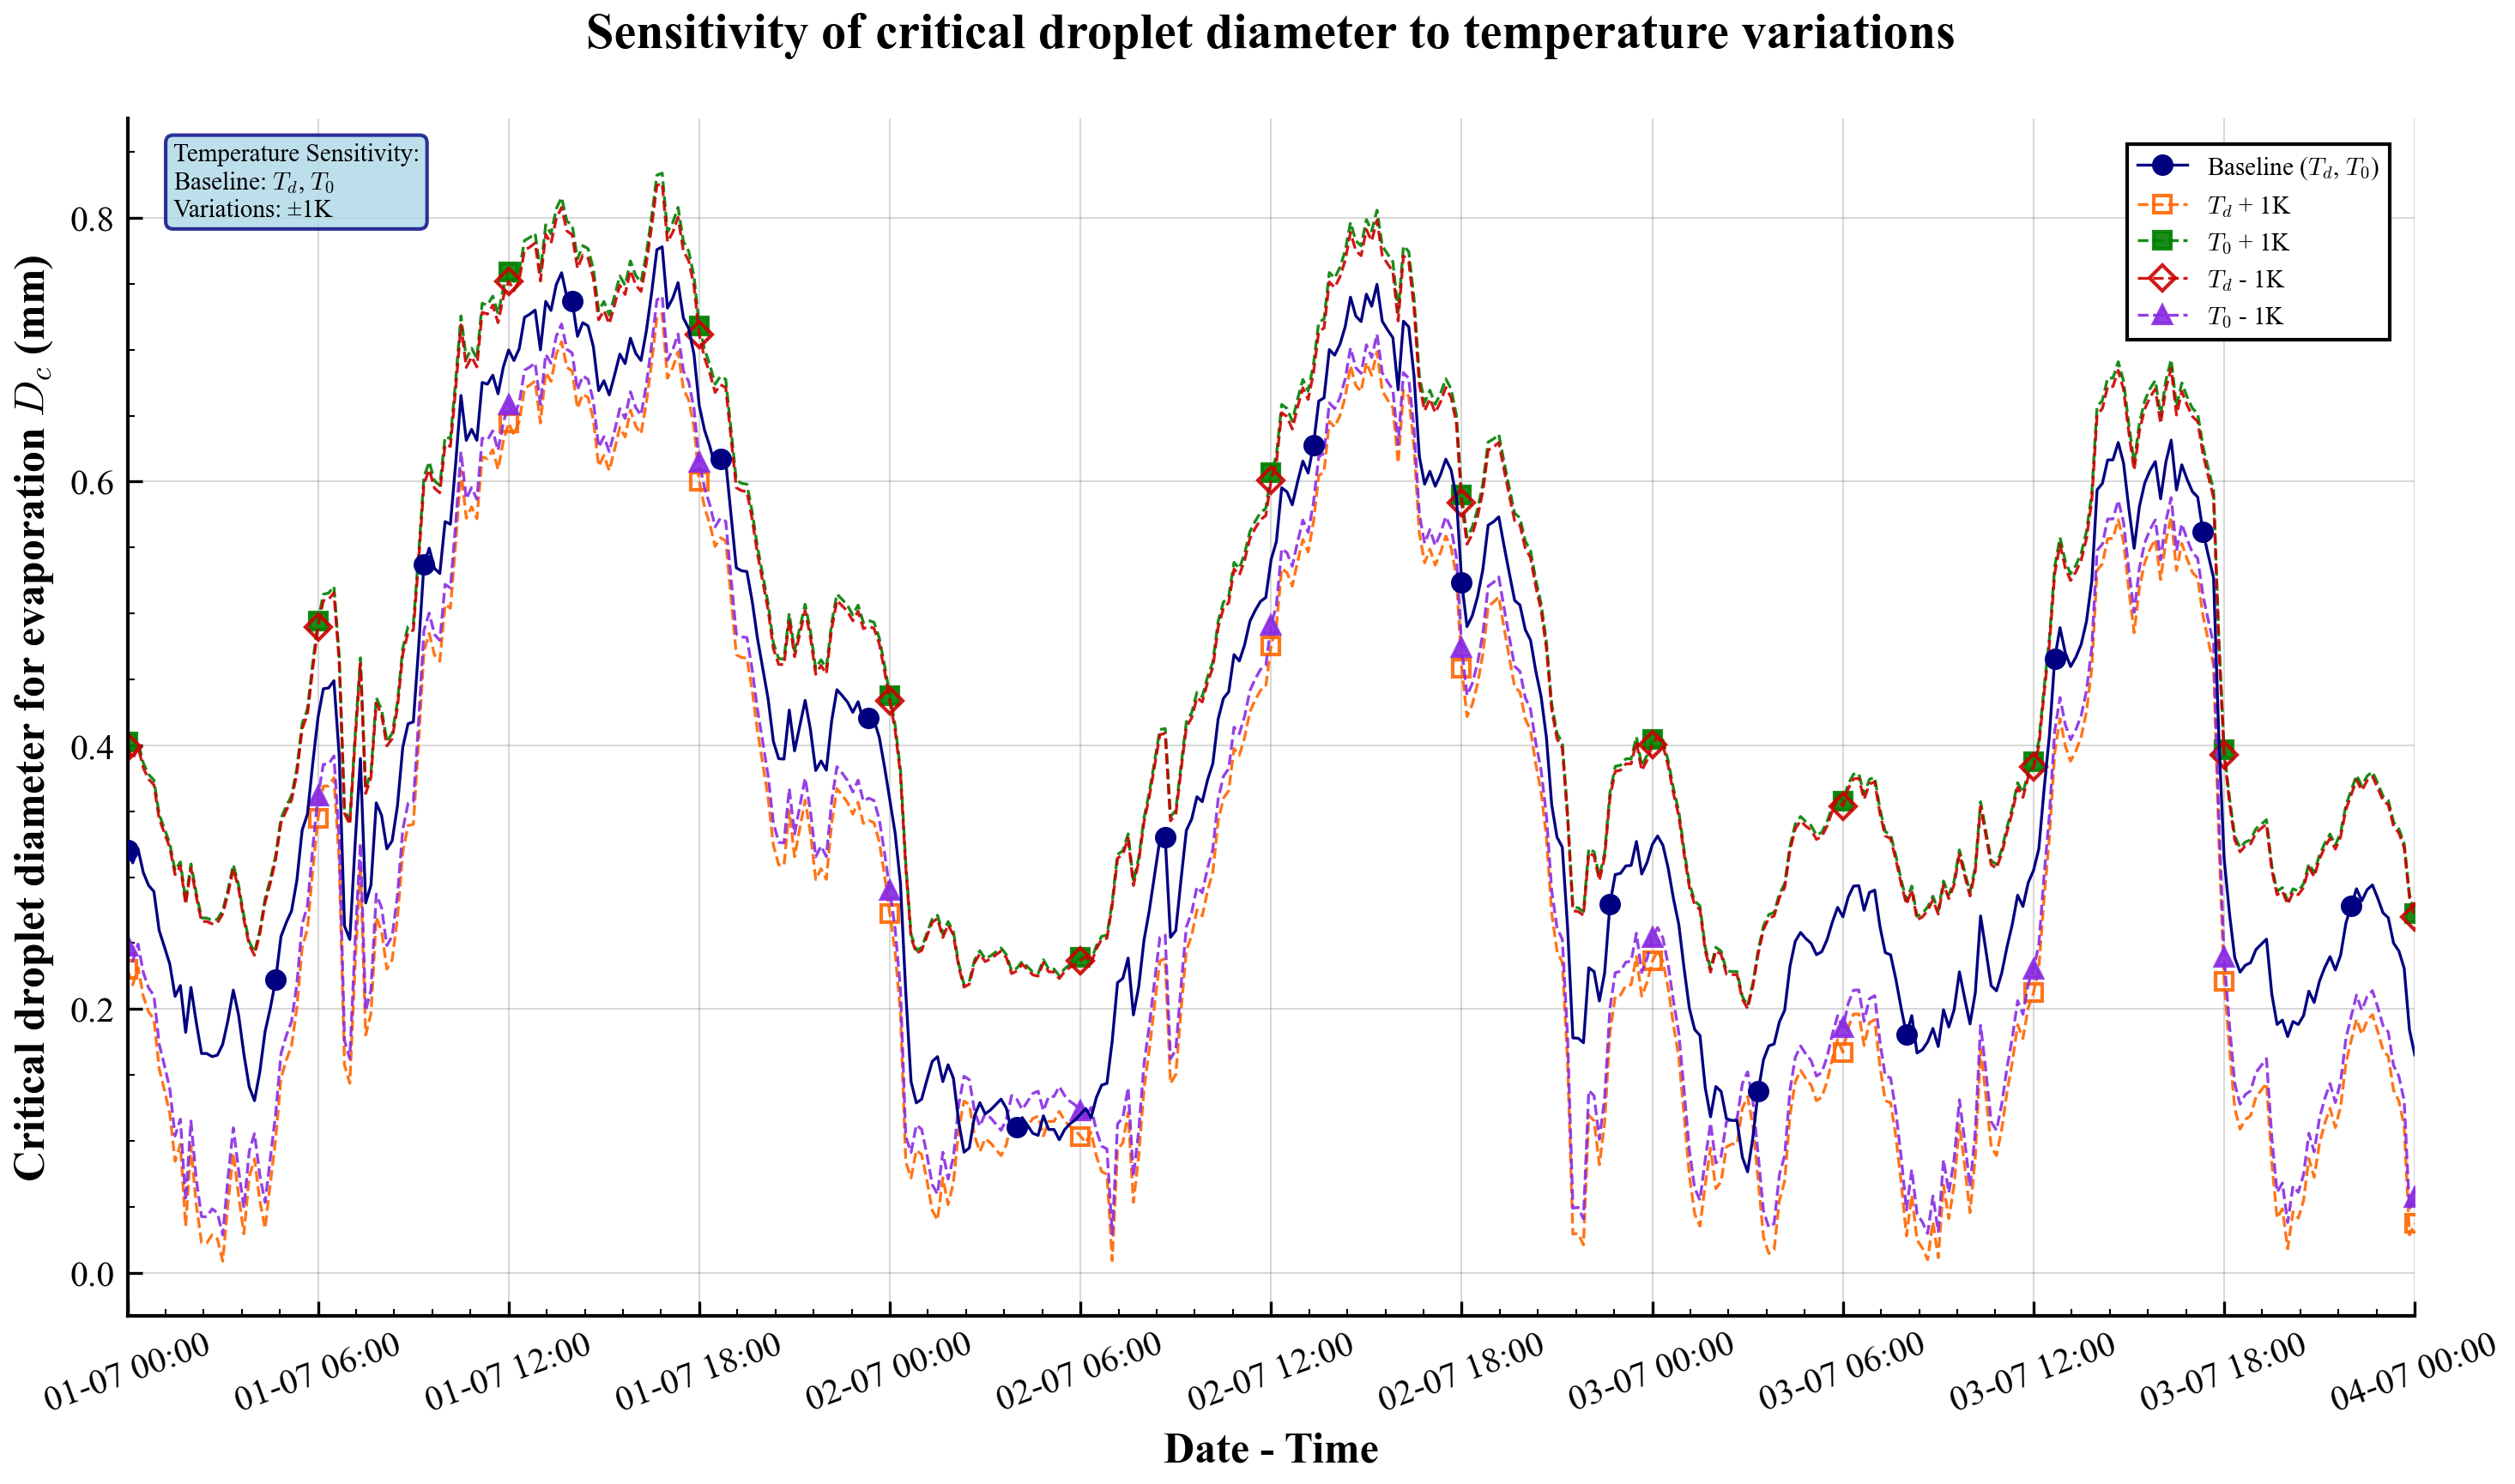

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Set scientific plotting style with professional formatting
SCALE_FACTOR = 1.0  # Adjust this to scale the entire plot

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    'legend.fontsize': 7 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',
})

# Create figure and axis
fig, ax = plt.subplots(figsize=(10 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Define colors, line styles, markers
colors = ['#000080', '#FF6600', '#008000', '#CC0000', '#8A2BE2']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
markers = ['o', 's', '^', 'D', 'v']
markersize = 5

# Baseline
ax.plot(time, D_c_arr[0] * 1000, 
        color=colors[0], linestyle=linestyles[0], linewidth=0.8,
        label=r'Baseline ($T_d$, $T_0$)', marker=markers[0],
        markersize=markersize, markevery=len(time)//15, zorder=5)

# T_d +1K vs T_0 +1K (coinciding)
ax.plot(time, D_c_arr[1] * 1000, 
        color=colors[1], linestyle='--', linewidth=0.8,
        label=r'$T_d$ + 1K', marker=markers[1], markerfacecolor='none',
        markersize=markersize, markevery=len(time)//12, alpha=0.9)

ax.plot(time_loaded, D_c_arr_loaded[1] * 1000, 
        color=colors[2], linestyle='--', linewidth=0.8,
        label=r'$T_0$ + 1K', marker=markers[1], markerfacecolor=colors[2],
        markersize=markersize, markevery=len(time_loaded)//12, alpha=0.9)

# T_d -1K vs T_0 -1K (coinciding)
ax.plot(time, D_c_arr[2] * 1000, 
        color=colors[3], linestyle='--', linewidth=0.8,
        label=r'$T_d$ - 1K', marker=markers[3], markerfacecolor='none',
        markersize=markersize, markevery=len(time)//12, alpha=0.9)

ax.plot(time_loaded, D_c_arr_loaded[2] * 1000 + 0.02, 
        color=colors[4], linestyle='--', linewidth=0.8,
        label=r'$T_0$ - 1K', marker=markers[2], markerfacecolor=colors[4],
        markersize=markersize, markevery=len(time_loaded)//12, alpha=0.9)

# Labels and title
ax.set_xlabel('Date - Time', fontweight='bold')
ax.set_ylabel('Critical droplet diameter for evaporation $D_c$ (mm)', fontweight='bold')
ax.set_title('Sensitivity of critical droplet diameter to temperature variations', 
             fontweight='bold', pad=20)

# Grid
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Legend
legend = ax.legend(loc='upper right', frameon=True, framealpha=1.0, 
                  edgecolor='black', facecolor='white', ncol=1,
                  borderaxespad=1 * SCALE_FACTOR)

# Tick formatting
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Date formatting
tick_interval = 6
date_format = '%d-%m %H:%M'
rotation = 20
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.set_xlim(time[0], time[-1])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Minor ticks
ax.minorticks_on()

# Layout
plt.tight_layout()

# Annotation box
textstr = '\n'.join([
    'Temperature Sensitivity:',
    r'Baseline: $T_d$, $T_0$',
    r'Variations: ±1K'
])
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8, edgecolor='navy')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=7*SCALE_FACTOR,
        verticalalignment='top', bbox=props)

plt.show()



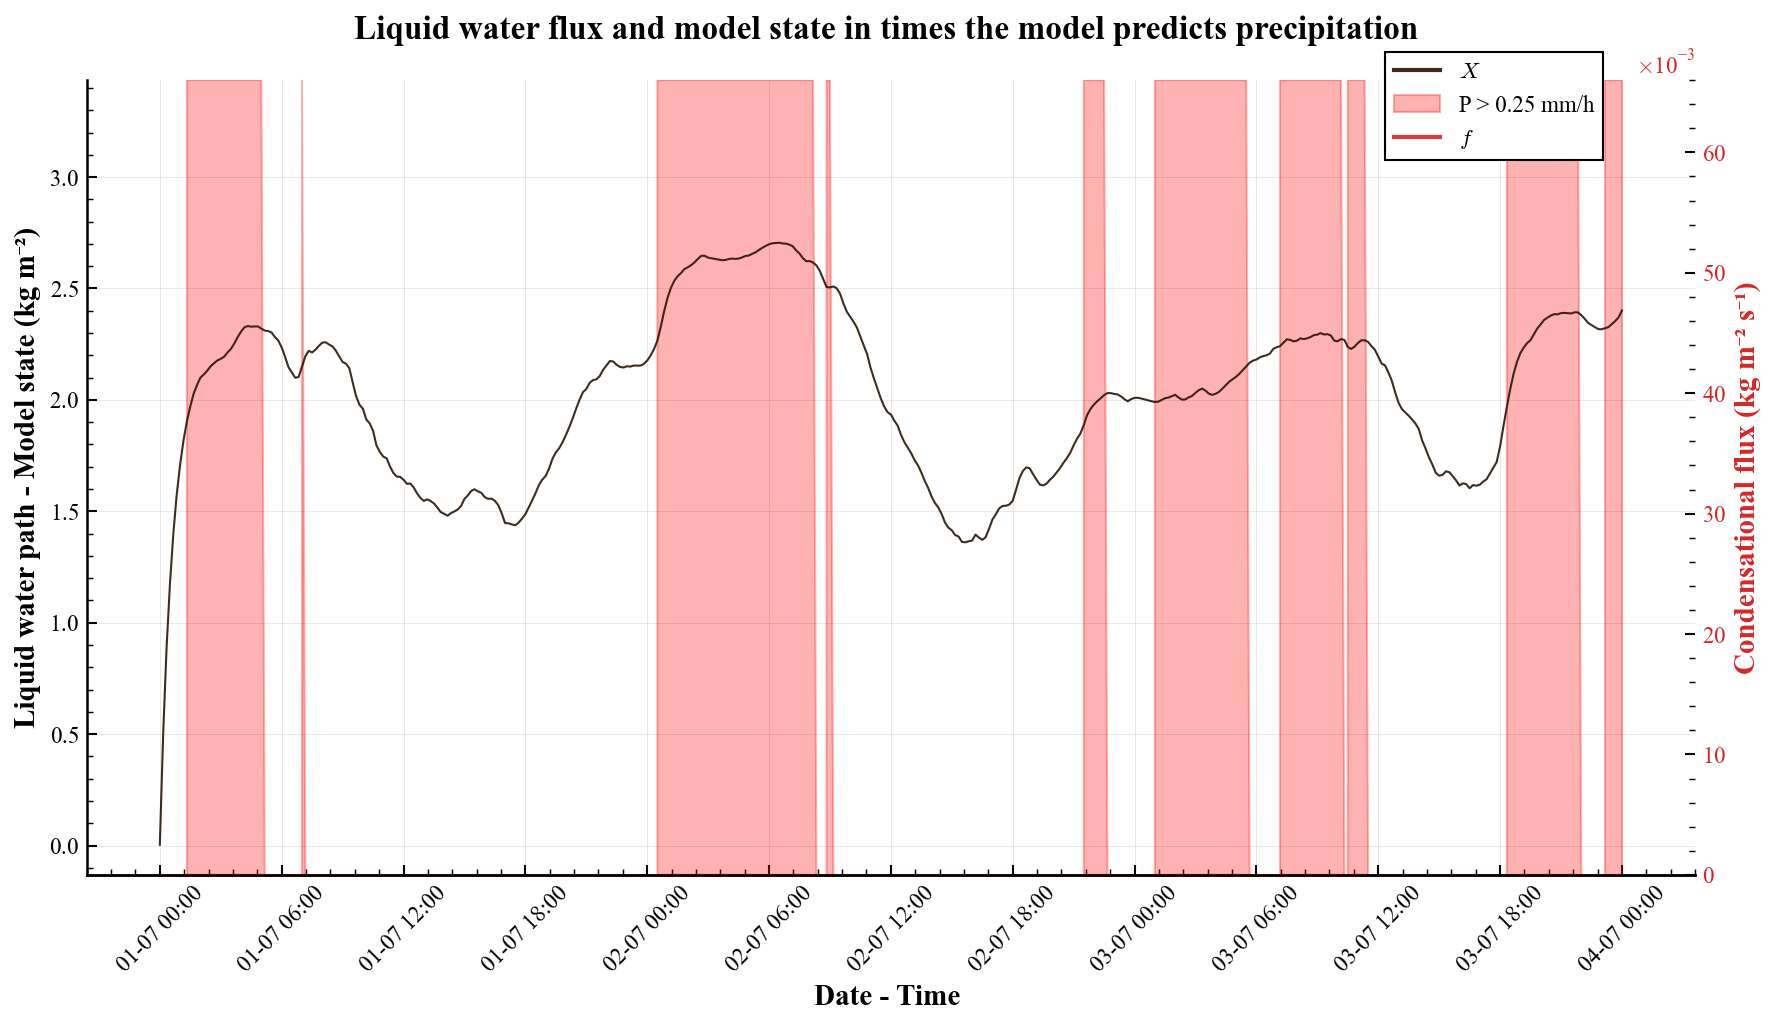

In [ ]:
from GB84 import alpha, epsilon_4
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Scientific color palette (colorblind-friendly)
colors = {
    'outflow_bottom': '#d62728',    # Red
    'outflow_top': '#2ca02c',       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#29160689",           # Orange
}

# Plot water fluxes on left axis (ax1)
line1 = ax1.plot(time, X[0], 
                color=colors['updraft'], 
                linestyle='-', 
                linewidth=1.0,
                label='$X$',
                alpha=0.9)

# Plot updraft velocity on right axis (ax2)
line4 = ax2.plot(time, f_arr[0], 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='$f$',
                alpha=0.9)
#ax1.hlines(y=np.min(X[mask]), xmin=time[mask].min(), xmax=time[mask].max(),)
# Set updraft velocity y-axis to start from 0 and leave space at top
ax2.set_ylim(bottom=0)

# Add space at the top of both axes for the legend
# Get current y-limits and extend them by 20% at the top
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()

ax1_range = ax1_ylim[1] - ax1_ylim[0]
ax2_range = ax2_ylim[1] - ax2_ylim[0]

ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * ax1_range)
ax2.set_ylim(0, ax2_ylim[1] + 0.2 * ax2_range)

# ADD PRECIPITATION SHADING HERE
# Get updated y-limits after extension for proper shading
y_min, y_max = ax1.get_ylim()

# Add red shaded areas for precipitation
# Assuming you have P*3600 and rain_rate variables
mask = (P[0]*3600 > 0.25).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.25)  # Handle xarray
#mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)

# Add precipitation shading to ax1 (spans full height)
ax1.fill_between(time, y_min, y_max, where=mask,
                 alpha=0.3, color='red', label='P > 0.25 mm/h', interpolate=True)

# Optionally add shading for actual rain rate with different color/alpha
#ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 #alpha=0.2, color='orange', label='Rain rate > 0.2 mm/h', interpolate=True)

# Scientific axis labels with proper units
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('Liquid water path - Model state (kg m⁻²)', color='black', fontweight='bold')
ax2.set_ylabel('Condensational flux (kg m⁻² s⁻¹)', color=colors['outflow_bottom'], fontweight='bold')
ax1.set_title('Liquid water flux and model state in times the model predicts precipitation ', fontweight='bold', pad=20)

# Tick colors
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['outflow_bottom'])

# Scientific grid (only on ax1 to avoid overlap)
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()
ax2.minorticks_on()

# Professional y-axis formatting with scientific notation at top for ax1
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.yaxis.get_offset_text().set_fontsize(11)

# Professional y-axis formatting for ax2
#ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#ax2.yaxis.get_offset_text().set_fontsize(11)
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
ax2.yaxis.get_major_formatter().set_powerlimits((-3, -3))
# Proper time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# Combine legends from both axes AND precipitation shading
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Scientific legend positioning
legend = ax1.legend(lines1 + lines2, labels1 + labels2,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1.05),
                   ncol=1)

# Set legend line width to match plot lines
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)


In [ ]:
plt.plot(time,f_arr)
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.3).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
#plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 #alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (433,) and (3, 433)

In [ ]:
product = v_arr*(w(T_d,p_surf) - w(T_t_arr,p_t_arr))
print(np.min(product[mask]),np.max(product[~mask]))

0.0010014430671754573 0.0010339175332586918


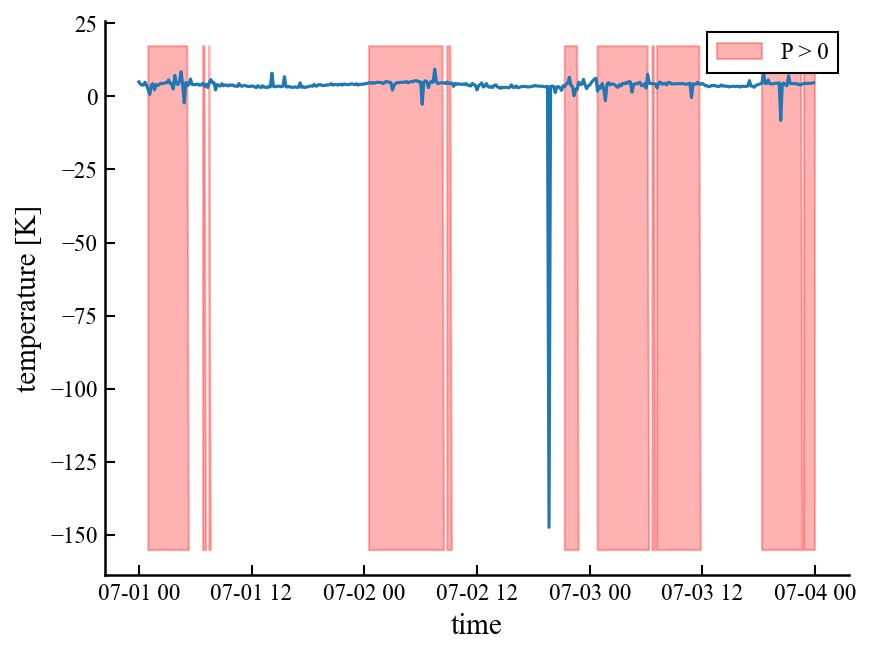

In [ ]:
diff = np.diff(f_arr)/f_arr[-1]/(np.diff(v_arr)/v_arr[-1])
ql = w(T_d,p_surf) - w(T_t_arr,p_t_arr)
diff_2 = np.diff(ql)/ql[-1]/(np.diff(v_arr)/v_arr[-1])
plt.plot(time[:-1],diff)
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.3).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
#plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 #alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()
plt.show()

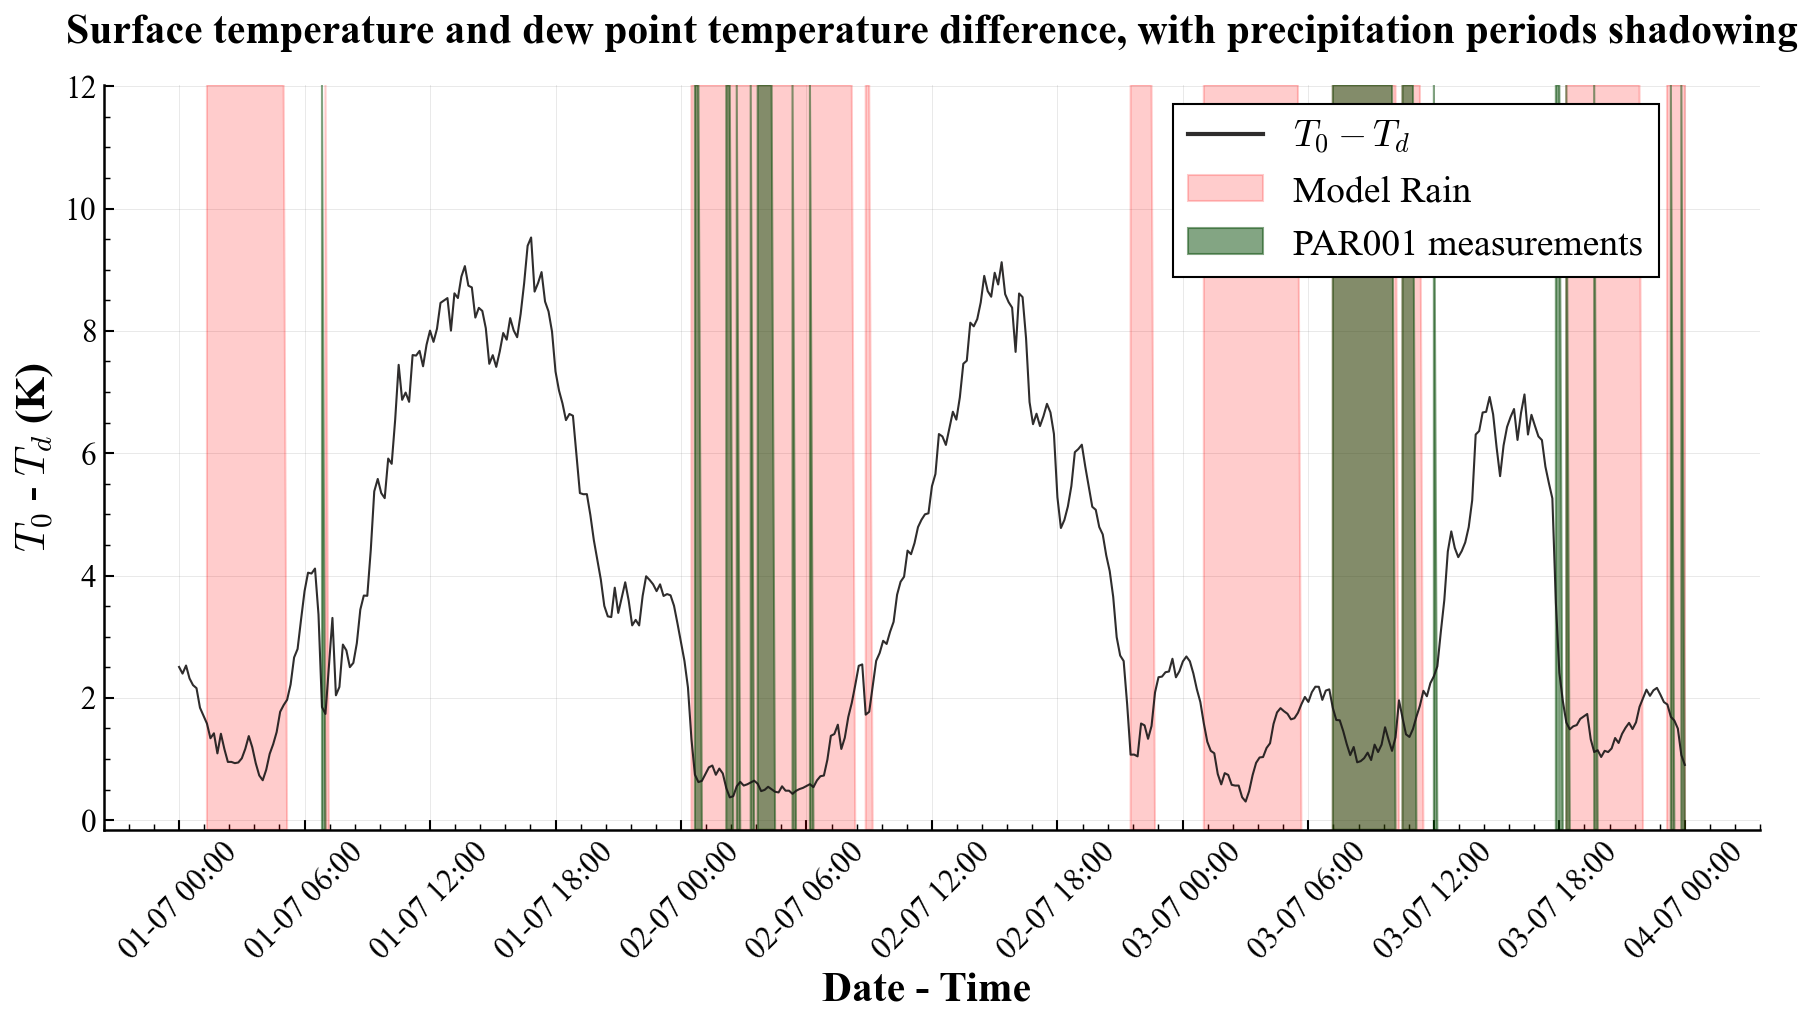

In [53]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,

    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',

    # Ticks
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,

    # Legend
    'legend.fontsize': 18,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,

    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Color palette
colors = {
    'outflow_bottom': "#755ec5",    # Red
    'outflow_top': "#155215",       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#181616EA",           # Orange
}

# --- Example plotting calls (replace with your arrays) ---
line1 = ax1.plot(time, T_surf - T_d_arr[0],
                 color=colors['updraft'],
                 linestyle='-',
                 linewidth=1.0,
                 label = '$T_0 - T_d$',
                 alpha=0.9)
"""
line2 = ax2.plot(time, D_c_arr[0]*1000, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='$D_c$',
                alpha=0.9)
"""

# Set y-limits
#ax2.set_ylim(bottom=0)

# Extend axes upward for legend space
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()
ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * (ax1_ylim[1] - ax1_ylim[0]))
ax2.set_ylim(ax2_ylim[0], ax2_ylim[1] + 0.2 * (ax2_ylim[1] - ax2_ylim[0]))

# --- Precipitation shading ---
y_min, y_max = ax1.get_ylim()

mask = (P[0] * 3600 > 0.25).values if hasattr(P[0], 'values') else (P[0] * 3600 > 0.25)
mask_actual = (rain_rate > 0.38).values if hasattr(rain_rate, 'values') else (rain_rate > 0.38)

ax1.fill_between(time, y_min, y_max, where=mask,
                 alpha=0.2, color='red', label='Model Rain',
                 interpolate=True)

ax1.fill_between(time, y_min, y_max, where=mask_actual,
                 alpha=0.5, color="#094d09", label='PAR001 measurements',
                 interpolate=True)

# --- Labels and title ---
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('$T_0$ - $T_d$ (K)', color='black', fontweight='bold')
#ax2.set_ylabel('Critical diameter $D_c$ (mm)', color=colors['outflow_bottom'], fontweight='bold')
ax1.set_title('Surface temperature and dew point temperature difference, with precipitation periods shadowing',
              fontweight='bold', pad=20)

# --- Formatting ---
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['outflow_bottom'])
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)
ax1.minorticks_on()
ax2.minorticks_on()

ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

ax2.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
ax2.yaxis.get_major_formatter().set_powerlimits((-1, -1))
# Time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
legend = ax1.legend(lines1 , labels1 ,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1),
                   ncol=1)

for line in legend.get_lines():
    line.set_linewidth(2.0)

plt.tight_layout()
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)


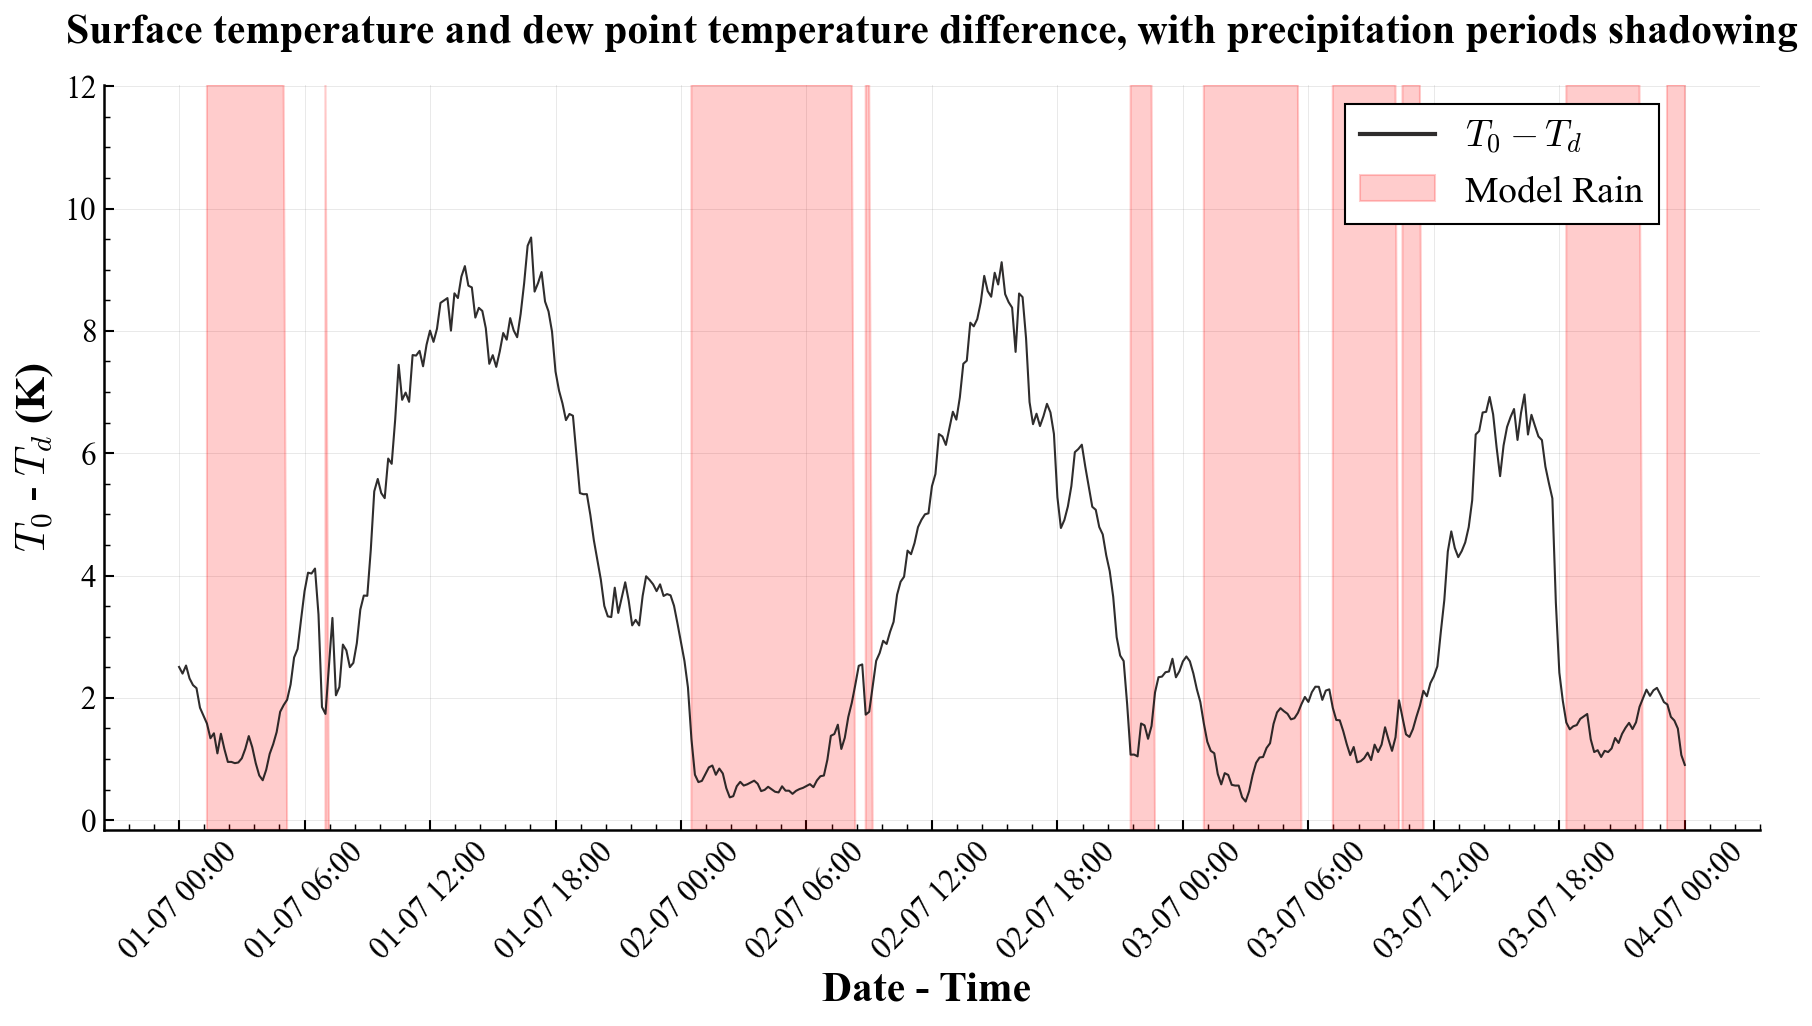

In [52]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,

    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',

    # Ticks
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,

    # Legend
    'legend.fontsize': 18,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,

    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))
#ax2 = ax1.twinx()

# Turn off right spine for ax1, left spine for ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Color palette
colors = {
    'outflow_bottom': "#755ec5",    # Red
    'outflow_top': "#155215",       # Green
    'inflow': '#1f77b4',            # Blue
    'updraft': "#181616EA",           # Orange
}

# --- Example plotting calls (replace with your arrays) ---
line1 = ax1.plot(time, T_surf - T_d_arr[0],
                 color=colors['updraft'],
                 linestyle='-',
                 linewidth=1.0,
                 label = '$T_0 - T_d$',
                 alpha=0.9)
"""
line2 = ax2.plot(time, D_c_arr[0]*1000, 
                color=colors['outflow_bottom'], 
                linestyle='-', 
                linewidth=1.0,
                label='$D_c$',
                alpha=0.9)
"""

# Set y-limits
#ax2.set_ylim(bottom=0)

# Extend axes upward for legend space
ax1_ylim = ax1.get_ylim()
ax2_ylim = ax2.get_ylim()
ax1.set_ylim(ax1_ylim[0], ax1_ylim[1] + 0.2 * (ax1_ylim[1] - ax1_ylim[0]))
ax2.set_ylim(ax2_ylim[0], ax2_ylim[1] + 0.2 * (ax2_ylim[1] - ax2_ylim[0]))

# --- Precipitation shading ---
y_min, y_max = ax1.get_ylim()

mask = (P[0] * 3600 > 0.25).values if hasattr(P[0], 'values') else (P[0] * 3600 > 0.25)
mask_actual = (rain_rate > 0.38).values if hasattr(rain_rate, 'values') else (rain_rate > 0.38)

ax1.fill_between(time, y_min, y_max, where=mask,
                 alpha=0.2, color='red', label='Model Rain',
                 interpolate=True)



# --- Labels and title ---
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_ylabel('$T_0$ - $T_d$ (K)', color='black', fontweight='bold')
#ax2.set_ylabel('Critical diameter $D_c$ (mm)', color=colors['outflow_bottom'], fontweight='bold')
ax1.set_title('Surface temperature and dew point temperature difference, with precipitation periods shadowing',
              fontweight='bold', pad=20)

# --- Formatting ---
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor=colors['outflow_bottom'])
ax1.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
ax1.set_axisbelow(True)
ax1.minorticks_on()
ax2.minorticks_on()

ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

ax2.yaxis.get_offset_text().set_fontsize(11)  # Control the size of the scientific notation
ax2.yaxis.get_major_formatter().set_powerlimits((-1, -1))
# Time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    ax1.set_xlabel('Date - Time ', fontweight='bold')
else:
    ax1.set_xlabel('Time (min)', fontweight='bold')
    ax1.xaxis.set_major_locator(MultipleLocator(360))
    ax1.set_xlim(left=0)

# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
legend = ax1.legend(lines1 , labels1 ,
                   loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1),
                   ncol=1)

for line in legend.get_lines():
    line.set_linewidth(2.0)

plt.tight_layout()
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
db1 = 10 * np.log10(radar_35.C1ZE.values)  # shape: (range1, time)
db2 = 10 * np.log10(radar_35.C2ZE.values)  # shape: (range2, time)
db3 = 10 * np.log10(radar_35.C3ZE.values)  # shape: (range2, time)

rho_1 = radar_35.C1RHV.values
rho_2 = radar_35.C2RHV.values
rho_3 = radar_35.C3RHV.values
time = radar_35.Time.values
z1 = radar_35.C1Range.values  # shape: (range1,)
z2 = radar_35.C2Range.values  # shape: (range2,)
z3 = radar_35.C3Range.values  # shape: (range2,)
db1 = db1.T   # → (37, 1245)
db2 = db2.T   # → (94, 1245)
db3 = db3.T
rho_1 = rho_1.T
rho_2 = rho_2.T
rho_3 = rho_3.T
db_combined = np.vstack([db1, db2,db3])   # (131, 1245)
rho_combined = np.vstack([rho_1, rho_2,rho_3])
z_combined  = np.concatenate([z1, z2,z3])


NameError: name 'radar_35' is not defined

In [ ]:
from scipy.stats import pearsonr

In [ ]:
r = pearsonr((T_surf)[mask] - T_d_arr[0,mask],P[0][mask])
print(r)

PearsonRResult(statistic=-0.790261250198824, pvalue=7.279870714165856e-13)


In [ ]:
r2 = pearsonr((T_surf)[mask],D_c_arr[0][mask])
print(r2)

PearsonRResult(statistic=0.12913355329358917, pvalue=0.3474097741369665)


In [ ]:
r3 = pearsonr((T_surf)[mask],P[0][mask])
print(r3)

PearsonRResult(statistic=-0.0019374371864099857, pvalue=0.939699935311685)


In [ ]:
max((T_surf - T_d_arr[0])[mask])

1.9177246

In [ ]:
min((T_surf - T_d_arr[0])[~mask])

1.7089844

In [ ]:
import numpy as np

from sklearn.linear_model import LinearRegression

# Create a linear regression object
regression = LinearRegression()
diff = (T_surf - T_d_arr[0])[mask].reshape(-1, 1)
# Fit the model to the data
reg = regression.fit(diff, P[0][mask])



In [ ]:
slice_str = "2024-07-16 00:00:00, 2024-07-17 00:00:00"
slice_tuple = tuple(slice_str.split(", "))

import numpy as np
import xarray as xr

# Load data
ground_measurements = xr.open_mfdataset(
    r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc'
)
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time', how='any')

# Slice time
measurements_used = measurements.sel(time=slice(*slice_tuple))

# Extract arrays
T_surf_lin = measurements_used.TA002.values
Td_surf_lin = measurements_used.TD002.values

# Build mask and predict
mask = (T_surf_lin - Td_surf_lin) < 1.91
#P_pred = reg.predict((T_surf_lin - Td_surf_lin)[mask].reshape(-1, 1))

# Fill into array of same length as T_surf_lin
P_lin = np.zeros(len(T_surf_lin))
#P_lin[mask] = P_pred


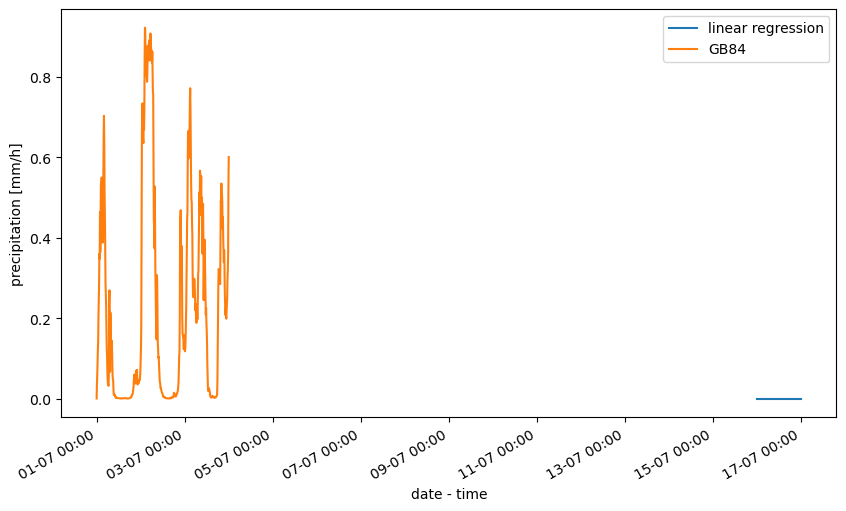

In [ ]:
plt.figure(figsize=(10,6))

# Plot your series
plt.plot(measurements_used.time, P_lin*3600, label='linear regression')
plt.plot(time, P[0]*3600, label='GB84')

# Labels
plt.ylabel('precipitation [mm/h]')
plt.xlabel('date - time')
plt.legend()

# Format x-axis as d-m hr
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
plt.gcf().autofmt_xdate()  # rotate labels nicely

plt.show()

In [ ]:
plt.plot(time,T_surf_lin)

ValueError: x and y must have same first dimension, but have shapes (433,) and (145,)